In [4]:
# ============================================
# CELL 1 — IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Library berhasil di-import.")

Library berhasil di-import.


In [6]:
# ============================================
# CELL 2 — DATASET PATH
# ============================================

DATA_PATH = Path("../data/raw/bank_transactions.csv")

print("Dataset path:")
print(DATA_PATH)

print("\nApakah file ditemukan?")
print(DATA_PATH.exists())

Dataset path:
..\data\raw\bank_transactions.csv

Apakah file ditemukan?
True


In [8]:
# ============================================
# CELL 3 — LOAD DATASET
# ============================================

df = pd.read_csv(DATA_PATH)

print("Dataset berhasil dibaca.")
print(f"Jumlah baris   : {df.shape[0]:,}")
print(f"Jumlah kolom   : {df.shape[1]:,}")

Dataset berhasil dibaca.
Jumlah baris   : 1,048,567
Jumlah kolom   : 9


In [10]:
# ============================================
# CELL 4 — PREVIEW DATA
# ============================================

df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [12]:
# ============================================
# CELL 5 — DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  str    
 1   CustomerID               1048567 non-null  str    
 2   CustomerDOB              1045170 non-null  str    
 3   CustGender               1047467 non-null  str    
 4   CustLocation             1048416 non-null  str    
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  str    
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 72.0 MB


In [14]:
# ============================================
# CELL 6 — COLUMN NAMES
# ============================================

print("=== DAFTAR KOLOM ===")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

=== DAFTAR KOLOM ===
1. TransactionID
2. CustomerID
3. CustomerDOB
4. CustGender
5. CustLocation
6. CustAccountBalance
7. TransactionDate
8. TransactionTime
9. TransactionAmount (INR)


In [16]:
# ============================================
# CELL 7 — DESCRIPTIVE STATISTICS
# ============================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,1048567,1048567,T1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1048567,884265,C4327447,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerDOB,1045170,17254,1/1/1800,57339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustGender,1047467,3,M,765530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustLocation,1048416,9355,MUMBAI,103595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustAccountBalance,1046198.0,NaN,NaN,NaN,115403.540056,846485.380601,0.0,4721.76,16792.18,57657.36,115035495.1
TransactionDate,1048567,55,7/8/16,27261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionTime,1048567.0,NaN,NaN,NaN,157087.529393,51261.854022,0.0,124030.0,164226.0,200010.0,235959.0
TransactionAmount (INR),1048567.0,NaN,NaN,NaN,1574.335003,6574.742978,0.0,161.0,459.03,1200.0,1560034.99


In [18]:
# ============================================
# CELL 8 — MISSING VALUE CHECK
# ============================================

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Value": missing_values,
    "Percentage": missing_percentage
})

print("=== MISSING VALUE CHECK ===")
print(missing_summary)

=== MISSING VALUE CHECK ===
                         Missing Value  Percentage
TransactionID                        0        0.00
CustomerID                           0        0.00
CustomerDOB                       3397        0.32
CustGender                        1100        0.10
CustLocation                       151        0.01
CustAccountBalance                2369        0.23
TransactionDate                      0        0.00
TransactionTime                      0        0.00
TransactionAmount (INR)              0        0.00


In [20]:
# ============================================
# CELL 9 — DUPLICATE CHECK
# ============================================

duplicate_rows = df.duplicated().sum()

print("=== DUPLICATE CHECK ===")
print(f"Jumlah duplicate rows : {duplicate_rows:,}")

=== DUPLICATE CHECK ===
Jumlah duplicate rows : 0


In [22]:
# ============================================
# CELL 10 — DUPLICATE TRANSACTION ID CHECK
# ============================================

duplicate_transaction_id = df["TransactionID"].duplicated().sum()

print("=== TRANSACTION ID CHECK ===")
print(f"Duplicate TransactionID : {duplicate_transaction_id:,}")

=== TRANSACTION ID CHECK ===
Duplicate TransactionID : 0


In [24]:
# ============================================
# CELL 11 — UNIQUE CUSTOMER GENDER
# ============================================

print("=== UNIQUE CUSTOMER GENDER ===")

print(df["CustGender"].value_counts(dropna=False))

=== UNIQUE CUSTOMER GENDER ===
CustGender
M      765530
F      281936
NaN      1100
T           1
Name: count, dtype: int64


In [26]:
# ============================================
# CELL 12 — TOP CUSTOMER LOCATIONS
# ============================================

top_locations = (
    df["CustLocation"]
    .value_counts(dropna=False)
    .head(20)
)

print("=== TOP 20 CUSTOMER LOCATIONS ===")
print(top_locations)

=== TOP 20 CUSTOMER LOCATIONS ===
CustLocation
MUMBAI         103595
NEW DELHI       84928
BANGALORE       81555
GURGAON         73818
DELHI           71019
NOIDA           32784
CHENNAI         30009
PUNE            25851
HYDERABAD       23049
THANE           21505
KOLKATA         19974
GHAZIABAD       15834
NAVI MUMBAI     13080
AHMEDABAD       12264
FARIDABAD       11318
JAIPUR           9921
CHANDIGARH       9526
LUCKNOW          7763
MOHALI           6741
SURAT            5770
Name: count, dtype: int64


In [30]:
# ============================================
# CELL 13 — TRANSACTION DATE CHECK
# ============================================

transaction_date = pd.to_datetime(
    df["TransactionDate"],
    errors="coerce",
    dayfirst=True,
    format="mixed"
)

print("=== TRANSACTION DATE CHECK ===")
print(f"Invalid date  : {transaction_date.isna().sum():,}")
print(f"Minimum date  : {transaction_date.min()}")
print(f"Maximum date  : {transaction_date.max()}")
print(f"Unique dates  : {transaction_date.nunique():,}")

=== TRANSACTION DATE CHECK ===
Invalid date  : 0
Minimum date  : 2016-08-01 00:00:00
Maximum date  : 2016-10-21 00:00:00
Unique dates  : 55


In [32]:
# ============================================
# CELL 14 — TRANSACTION TIME VALIDATION
# ============================================

time_numeric = pd.to_numeric(
    df["TransactionTime"],
    errors="coerce"
)

invalid_time = (
    (time_numeric < 0) |
    (time_numeric > 235959)
).sum()

print("=== TRANSACTION TIME VALIDATION ===")
print(f"Invalid TransactionTime : {invalid_time:,}")
print(f"Minimum TransactionTime : {time_numeric.min():.0f}")
print(f"Maximum TransactionTime : {time_numeric.max():.0f}")

=== TRANSACTION TIME VALIDATION ===
Invalid TransactionTime : 0
Minimum TransactionTime : 0
Maximum TransactionTime : 235959


In [34]:
# ============================================
# CELL 15 — TRANSACTION AMOUNT VALIDATION
# ============================================

transaction_amount = df["TransactionAmount (INR)"]

print("=== TRANSACTION AMOUNT VALIDATION ===")
print(f"Negative amount : {(transaction_amount < 0).sum():,}")
print(f"Zero amount     : {(transaction_amount == 0).sum():,}")
print(f"Minimum amount  : {transaction_amount.min():,.2f}")
print(f"Maximum amount  : {transaction_amount.max():,.2f}")

=== TRANSACTION AMOUNT VALIDATION ===
Negative amount : 0
Zero amount     : 835
Minimum amount  : 0.00
Maximum amount  : 1,560,034.99


In [36]:
# ============================================
# CELL 16 — ACCOUNT BALANCE VALIDATION
# ============================================

account_balance = df["CustAccountBalance"]

print("=== ACCOUNT BALANCE VALIDATION ===")
print(f"Negative balance : {(account_balance < 0).sum():,}")
print(f"Zero balance     : {(account_balance == 0).sum():,}")
print(f"Minimum balance  : {account_balance.min():,.2f}")
print(f"Maximum balance  : {account_balance.max():,.2f}")

=== ACCOUNT BALANCE VALIDATION ===
Negative balance : 0
Zero balance     : 2,711
Minimum balance  : 0.00
Maximum balance  : 115,035,495.10


In [38]:
# ============================================
# CELL 17 — CREATE CLEANING DATAFRAME
# ============================================

df_clean = df.copy()

print("Data cleaning dataframe berhasil dibuat.")
print(f"Jumlah baris : {df_clean.shape[0]:,}")
print(f"Jumlah kolom : {df_clean.shape[1]:,}")

Data cleaning dataframe berhasil dibuat.
Jumlah baris : 1,048,567
Jumlah kolom : 9


In [40]:
# ============================================
# CELL 18 — CLEAN CUSTOMER DOB
# ============================================

# Konversi CustomerDOB menjadi format datetime
df_clean["CustomerDOB"] = pd.to_datetime(
    df_clean["CustomerDOB"],
    errors="coerce",
    dayfirst=True,
    format="mixed"
)

# Tandai tanggal lahir yang tidak realistis
invalid_dob = (
    (df_clean["CustomerDOB"].dt.year < 1900) |
    (df_clean["CustomerDOB"].dt.year > 2016)
)

# Ubah DOB yang tidak realistis menjadi missing value
df_clean.loc[invalid_dob, "CustomerDOB"] = pd.NaT

print("=== CUSTOMER DOB CLEANING ===")
print(f"Missing CustomerDOB : {df_clean['CustomerDOB'].isna().sum():,}")
print(f"Valid CustomerDOB   : {df_clean['CustomerDOB'].notna().sum():,}")
print(f"Minimum DOB         : {df_clean['CustomerDOB'].min()}")
print(f"Maximum DOB         : {df_clean['CustomerDOB'].max()}")

=== CUSTOMER DOB CLEANING ===
Missing CustomerDOB : 178,314
Valid CustomerDOB   : 870,253
Minimum DOB         : 1976-01-01 00:00:00
Maximum DOB         : 2016-02-22 00:00:00


In [42]:
# ============================================
# CELL 19 — CLEAN CUSTOMER GENDER
# ============================================

# Ubah nilai gender yang tidak valid menjadi missing value
df_clean.loc[
    ~df_clean["CustGender"].isin(["M", "F"]),
    "CustGender"
] = np.nan

# Isi missing gender dengan kategori Unknown
df_clean["CustGender"] = df_clean["CustGender"].fillna("Unknown")

print("=== CUSTOMER GENDER CLEANING ===")
print(df_clean["CustGender"].value_counts(dropna=False))

=== CUSTOMER GENDER CLEANING ===
CustGender
M          765530
F          281936
Unknown      1101
Name: count, dtype: int64


In [44]:
# ============================================
# CELL 20 — CLEAN CUSTOMER LOCATION
# ============================================

# Isi missing customer location dengan kategori Unknown
df_clean["CustLocation"] = df_clean["CustLocation"].fillna("Unknown")

print("=== CUSTOMER LOCATION CLEANING ===")
print(f"Missing CustLocation : {df_clean['CustLocation'].isna().sum():,}")
print(f"Jumlah lokasi        : {df_clean['CustLocation'].nunique():,}")

print("\nTop 20 Customer Locations:")
print(df_clean["CustLocation"].value_counts().head(20))

=== CUSTOMER LOCATION CLEANING ===
Missing CustLocation : 0
Jumlah lokasi        : 9,356

Top 20 Customer Locations:
CustLocation
MUMBAI         103595
NEW DELHI       84928
BANGALORE       81555
GURGAON         73818
DELHI           71019
NOIDA           32784
CHENNAI         30009
PUNE            25851
HYDERABAD       23049
THANE           21505
KOLKATA         19974
GHAZIABAD       15834
NAVI MUMBAI     13080
AHMEDABAD       12264
FARIDABAD       11318
JAIPUR           9921
CHANDIGARH       9526
LUCKNOW          7763
MOHALI           6741
SURAT            5770
Name: count, dtype: int64


In [46]:
# ============================================
# CELL 21 — ACCOUNT BALANCE CHECK
# ============================================

print("=== ACCOUNT BALANCE CHECK ===")

print(f"Missing balance : {df_clean['CustAccountBalance'].isna().sum():,}")
print(f"Negative balance: {(df_clean['CustAccountBalance'] < 0).sum():,}")
print(f"Zero balance    : {(df_clean['CustAccountBalance'] == 0).sum():,}")

print("\nBalance statistics:")
print(df_clean["CustAccountBalance"].describe())

=== ACCOUNT BALANCE CHECK ===
Missing balance : 2,369
Negative balance: 0
Zero balance    : 2,711

Balance statistics:
count    1.046198e+06
mean     1.154035e+05
std      8.464854e+05
min      0.000000e+00
25%      4.721760e+03
50%      1.679218e+04
75%      5.765736e+04
max      1.150355e+08
Name: CustAccountBalance, dtype: float64


In [48]:
# ============================================
# CELL 22 — CLEAN TRANSACTION DATE
# ============================================

# Konversi TransactionDate menjadi datetime
df_clean["TransactionDate"] = pd.to_datetime(
    df_clean["TransactionDate"],
    errors="coerce",
    dayfirst=True,
    format="mixed"
)

print("=== TRANSACTION DATE CLEANING ===")
print(f"Missing TransactionDate : {df_clean['TransactionDate'].isna().sum():,}")
print(f"Minimum TransactionDate : {df_clean['TransactionDate'].min()}")
print(f"Maximum TransactionDate : {df_clean['TransactionDate'].max()}")
print(f"Unique TransactionDate  : {df_clean['TransactionDate'].nunique():,}")

=== TRANSACTION DATE CLEANING ===
Missing TransactionDate : 0
Minimum TransactionDate : 2016-08-01 00:00:00
Maximum TransactionDate : 2016-10-21 00:00:00
Unique TransactionDate  : 55


In [50]:
# ============================================
# CELL 23 — CLEAN TRANSACTION TIME
# ============================================

# Pastikan TransactionTime berupa angka
df_clean["TransactionTime"] = pd.to_numeric(
    df_clean["TransactionTime"],
    errors="coerce"
)

# Ubah menjadi format HH:MM:SS
df_clean["TransactionTimeFormatted"] = pd.to_datetime(
    df_clean["TransactionTime"].astype("Int64").astype(str).str.zfill(6),
    format="%H%M%S",
    errors="coerce"
).dt.time

print("=== TRANSACTION TIME CLEANING ===")
print(f"Missing TransactionTime          : {df_clean['TransactionTime'].isna().sum():,}")
print(f"Invalid formatted time           : {df_clean['TransactionTimeFormatted'].isna().sum():,}")

print("\nContoh TransactionTime:")
print(
    df_clean[
        ["TransactionTime", "TransactionTimeFormatted"]
    ].head(10)
)

=== TRANSACTION TIME CLEANING ===
Missing TransactionTime          : 0
Invalid formatted time           : 0

Contoh TransactionTime:
   TransactionTime TransactionTimeFormatted
0           143207                 14:32:07
1           141858                 14:18:58
2           142712                 14:27:12
3           142714                 14:27:14
4           181156                 18:11:56
5           173940                 17:39:40
6           173806                 17:38:06
7           170537                 17:05:37
8           192825                 19:28:25
9           192446                 19:24:46


In [52]:
# ============================================
# CELL 24 — CREATE TRANSACTION DATETIME
# ============================================

df_clean["TransactionDateTime"] = pd.to_datetime(
    df_clean["TransactionDate"].dt.strftime("%Y-%m-%d")
    + " "
    + df_clean["TransactionTimeFormatted"].astype(str),
    errors="coerce"
)

print("=== TRANSACTION DATETIME ===")
print(f"Missing TransactionDateTime : {df_clean['TransactionDateTime'].isna().sum():,}")

print("\nContoh TransactionDateTime:")
print(
    df_clean[
        ["TransactionDate", "TransactionTimeFormatted", "TransactionDateTime"]
    ].head(10)
)

=== TRANSACTION DATETIME ===
Missing TransactionDateTime : 0

Contoh TransactionDateTime:
  TransactionDate TransactionTimeFormatted TransactionDateTime
0      2016-08-02                 14:32:07 2016-08-02 14:32:07
1      2016-08-02                 14:18:58 2016-08-02 14:18:58
2      2016-08-02                 14:27:12 2016-08-02 14:27:12
3      2016-08-02                 14:27:14 2016-08-02 14:27:14
4      2016-08-02                 18:11:56 2016-08-02 18:11:56
5      2016-08-02                 17:39:40 2016-08-02 17:39:40
6      2016-08-02                 17:38:06 2016-08-02 17:38:06
7      2016-08-02                 17:05:37 2016-08-02 17:05:37
8      2016-08-02                 19:28:25 2016-08-02 19:28:25
9      2016-08-02                 19:24:46 2016-08-02 19:24:46


In [54]:
# ============================================
# CELL 25 — CREATE TRANSACTION HOUR
# ============================================

df_clean["TransactionHour"] = (
    df_clean["TransactionDateTime"].dt.hour
)

print("=== TRANSACTION HOUR ===")
print(f"Missing TransactionHour : {df_clean['TransactionHour'].isna().sum():,}")
print(f"Minimum hour            : {df_clean['TransactionHour'].min()}")
print(f"Maximum hour            : {df_clean['TransactionHour'].max()}")

print("\nJumlah transaksi per jam:")
print(
    df_clean["TransactionHour"]
    .value_counts()
    .sort_index()
)

=== TRANSACTION HOUR ===
Missing TransactionHour : 0
Minimum hour            : 0
Maximum hour            : 23

Jumlah transaksi per jam:
TransactionHour
0     17977
1      8851
2      5553
3      4720
4      4571
5      5359
6      8218
7     14579
8     23523
9     33098
10    42645
11    52410
12    60879
13    65019
14    66554
15    64853
16    64357
17    69222
18    79332
19    94396
20    97053
21    80105
22    53529
23    31764
Name: count, dtype: int64


In [56]:
# ============================================
# CELL 26 — CLEAN TRANSACTION AMOUNT
# ============================================

# Pastikan TransactionAmount bertipe numerik
df_clean["TransactionAmount (INR)"] = pd.to_numeric(
    df_clean["TransactionAmount (INR)"],
    errors="coerce"
)

# Cek kondisi transaction amount
missing_amount = df_clean["TransactionAmount (INR)"].isna().sum()
negative_amount = (
    df_clean["TransactionAmount (INR)"] < 0
).sum()
zero_amount = (
    df_clean["TransactionAmount (INR)"] == 0
).sum()

print("=== TRANSACTION AMOUNT CLEANING ===")
print(f"Missing amount   : {missing_amount:,}")
print(f"Negative amount  : {negative_amount:,}")
print(f"Zero amount      : {zero_amount:,}")

print("\nTransaction amount statistics:")
print(df_clean["TransactionAmount (INR)"].describe())

=== TRANSACTION AMOUNT CLEANING ===
Missing amount   : 0
Negative amount  : 0
Zero amount      : 835

Transaction amount statistics:
count    1.048567e+06
mean     1.574335e+03
std      6.574743e+03
min      0.000000e+00
25%      1.610000e+02
50%      4.590300e+02
75%      1.200000e+03
max      1.560035e+06
Name: TransactionAmount (INR), dtype: float64


In [58]:
# ============================================
# CELL 27 — CREATE TIME FEATURES
# ============================================

df_clean["TransactionYear"] = (
    df_clean["TransactionDateTime"].dt.year
)

df_clean["TransactionMonth"] = (
    df_clean["TransactionDateTime"].dt.month
)

df_clean["TransactionDay"] = (
    df_clean["TransactionDateTime"].dt.day
)

print("=== TIME FEATURES ===")
print(
    df_clean[
        [
            "TransactionDate",
            "TransactionDateTime",
            "TransactionYear",
            "TransactionMonth",
            "TransactionDay",
            "TransactionHour"
        ]
    ].head(10)
)

=== TIME FEATURES ===
  TransactionDate TransactionDateTime  TransactionYear  TransactionMonth  \
0      2016-08-02 2016-08-02 14:32:07             2016                 8   
1      2016-08-02 2016-08-02 14:18:58             2016                 8   
2      2016-08-02 2016-08-02 14:27:12             2016                 8   
3      2016-08-02 2016-08-02 14:27:14             2016                 8   
4      2016-08-02 2016-08-02 18:11:56             2016                 8   
5      2016-08-02 2016-08-02 17:39:40             2016                 8   
6      2016-08-02 2016-08-02 17:38:06             2016                 8   
7      2016-08-02 2016-08-02 17:05:37             2016                 8   
8      2016-08-02 2016-08-02 19:28:25             2016                 8   
9      2016-08-02 2016-08-02 19:24:46             2016                 8   

   TransactionDay  TransactionHour  
0               2               14  
1               2               14  
2               2             

In [60]:
# ============================================
# CELL 28 — CREATE TRANSACTION MONTH NAME
# ============================================

df_clean["TransactionMonthName"] = (
    df_clean["TransactionDateTime"].dt.month_name()
)

print("=== TRANSACTION MONTH NAME ===")
print(
    df_clean[
        [
            "TransactionDate",
            "TransactionMonth",
            "TransactionMonthName"
        ]
    ].head(10)
)

print("\nUnique month names:")
print(
    df_clean["TransactionMonthName"]
    .drop_duplicates()
    .tolist()
)

=== TRANSACTION MONTH NAME ===
  TransactionDate  TransactionMonth TransactionMonthName
0      2016-08-02                 8               August
1      2016-08-02                 8               August
2      2016-08-02                 8               August
3      2016-08-02                 8               August
4      2016-08-02                 8               August
5      2016-08-02                 8               August
6      2016-08-02                 8               August
7      2016-08-02                 8               August
8      2016-08-02                 8               August
9      2016-08-02                 8               August

Unique month names:
['August', 'October', 'September']


In [62]:
# ============================================
# CELL 29 — CREATE TRANSACTION DAY OF WEEK
# ============================================

df_clean["TransactionDayName"] = (
    df_clean["TransactionDateTime"].dt.day_name()
)

print("=== TRANSACTION DAY OF WEEK ===")

print(
    df_clean[
        [
            "TransactionDate",
            "TransactionDay",
            "TransactionDayName",
            "TransactionHour"
        ]
    ].head(10)
)

print("\nUnique day names:")
print(
    df_clean["TransactionDayName"]
    .drop_duplicates()
    .tolist()
)

print("\nJumlah transaksi per hari:")
print(
    df_clean["TransactionDayName"]
    .value_counts()
)

=== TRANSACTION DAY OF WEEK ===
  TransactionDate  TransactionDay TransactionDayName  TransactionHour
0      2016-08-02               2            Tuesday               14
1      2016-08-02               2            Tuesday               14
2      2016-08-02               2            Tuesday               14
3      2016-08-02               2            Tuesday               14
4      2016-08-02               2            Tuesday               18
5      2016-08-02               2            Tuesday               17
6      2016-08-02               2            Tuesday               17
7      2016-08-02               2            Tuesday               17
8      2016-08-02               2            Tuesday               19
9      2016-08-02               2            Tuesday               19

Unique day names:
['Tuesday', 'Monday', 'Wednesday', 'Friday', 'Thursday', 'Saturday', 'Sunday']

Jumlah transaksi per hari:
TransactionDayName
Sunday       171771
Monday       155525
Thursday     

In [64]:
# ============================================
# CELL 30 — CALCULATE CUSTOMER AGE
# ============================================

df_clean["CustomerAge"] = (
    (
        df_clean["TransactionDateTime"]
        - df_clean["CustomerDOB"]
    ).dt.days / 365.25
).round(1)

print("=== CUSTOMER AGE CHECK ===")

print(f"Missing CustomerAge : {df_clean['CustomerAge'].isna().sum():,}")

print(f"Minimum CustomerAge : {df_clean['CustomerAge'].min()}")
print(f"Maximum CustomerAge : {df_clean['CustomerAge'].max()}")

print("\nCustomer age statistics:")
print(df_clean["CustomerAge"].describe())

=== CUSTOMER AGE CHECK ===
Missing CustomerAge : 178,314
Minimum CustomerAge : 0.5
Maximum CustomerAge : 40.8

Customer age statistics:
count    870253.000000
mean         28.684892
std           4.992866
min           0.500000
25%          24.900000
50%          28.000000
75%          32.100000
max          40.800000
Name: CustomerAge, dtype: float64


In [66]:
# ============================================
# CELL 31 — VALIDATE CUSTOMER AGE
# ============================================

# Tandai usia yang tidak realistis untuk analisis nasabah dewasa
invalid_age = (
    (df_clean["CustomerAge"] < 18) |
    (df_clean["CustomerAge"] > 100)
)

# Ubah usia yang tidak realistis menjadi missing value
df_clean.loc[invalid_age, "CustomerAge"] = np.nan

print("=== CUSTOMER AGE VALIDATION ===")

print(f"Invalid CustomerAge : {invalid_age.sum():,}")
print(f"Missing CustomerAge : {df_clean['CustomerAge'].isna().sum():,}")
print(f"Valid CustomerAge   : {df_clean['CustomerAge'].notna().sum():,}")

print("\nValid customer age statistics:")
print(df_clean["CustomerAge"].describe())

=== CUSTOMER AGE VALIDATION ===
Invalid CustomerAge : 1,926
Missing CustomerAge : 180,240
Valid CustomerAge   : 868,327

Valid customer age statistics:
count    868327.000000
mean         28.715011
std           4.954130
min          18.000000
25%          24.900000
50%          28.000000
75%          32.100000
max          40.800000
Name: CustomerAge, dtype: float64


In [68]:
# ============================================
# CELL 32 — FINAL MISSING VALUE CHECK
# ============================================

missing_values_clean = df_clean.isnull().sum()

missing_percentage_clean = (
    df_clean.isnull().mean() * 100
).round(2)

missing_summary_clean = pd.DataFrame({
    "Missing Value": missing_values_clean,
    "Percentage": missing_percentage_clean
})

print("=== FINAL MISSING VALUE CHECK ===")
print(missing_summary_clean)

=== FINAL MISSING VALUE CHECK ===
                          Missing Value  Percentage
TransactionID                         0        0.00
CustomerID                            0        0.00
CustomerDOB                      178314       17.01
CustGender                            0        0.00
CustLocation                          0        0.00
CustAccountBalance                 2369        0.23
TransactionDate                       0        0.00
TransactionTime                       0        0.00
TransactionAmount (INR)               0        0.00
TransactionTimeFormatted              0        0.00
TransactionDateTime                   0        0.00
TransactionHour                       0        0.00
TransactionYear                       0        0.00
TransactionMonth                      0        0.00
TransactionDay                        0        0.00
TransactionMonthName                  0        0.00
TransactionDayName                    0        0.00
CustomerAge                   

In [74]:
# ============================================
# CELL 33 — FINAL DATA QUALITY CHECK
# ============================================

print("=== FINAL DATA QUALITY CHECK ===")

print(f"Jumlah baris       : {df_clean.shape[0]:,}")
print(f"Jumlah kolom       : {df_clean.shape[1]:,}")

duplicate_rows_clean = df_clean.duplicated().sum()

duplicate_transaction_id_clean = (
    df_clean["TransactionID"].duplicated().sum()
)

main_transaction_columns = [
    "TransactionID",
    "CustomerID",
    "TransactionDate",
    "TransactionTime",
    "TransactionAmount (INR)"
]

missing_main_transaction = (
    df_clean[main_transaction_columns]
    .isnull()
    .sum()
)

print("\n=== DUPLICATE CHECK ===")
print(f"Duplicate rows          : {duplicate_rows_clean:,}")
print(f"Duplicate TransactionID : {duplicate_transaction_id_clean:,}")

print("\n=== MAIN TRANSACTION COLUMNS ===")
print(missing_main_transaction)

print("\n=== FINAL DATA QUALITY STATUS ===")

if (
    duplicate_rows_clean == 0
    and duplicate_transaction_id_clean == 0
    and missing_main_transaction.sum() == 0
):
    print("PASS — Data utama siap untuk tahap analisis.")
else:
    print("CHECK — Masih terdapat masalah pada data utama.")

=== FINAL DATA QUALITY CHECK ===
Jumlah baris       : 1,048,567
Jumlah kolom       : 18

=== DUPLICATE CHECK ===
Duplicate rows          : 0
Duplicate TransactionID : 0

=== MAIN TRANSACTION COLUMNS ===
TransactionID              0
CustomerID                 0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64

=== FINAL DATA QUALITY STATUS ===
PASS — Data utama siap untuk tahap analisis.


In [76]:
# ============================================
# CELL 34 — EXPORT CLEAN DATASET
# ============================================

# Menentukan folder penyimpanan dataset hasil cleaning
PROCESSED_PATH = Path("../data/processed")

# Membuat folder jika belum tersedia
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

# Menentukan nama file hasil cleaning
CLEAN_DATA_PATH = (
    PROCESSED_PATH / "bank_transactions_clean.csv"
)

# Menyimpan dataset hasil cleaning
df_clean.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print("=== CLEAN DATASET EXPORT ===")
print(f"File berhasil disimpan : {CLEAN_DATA_PATH}")
print(f"Jumlah baris           : {df_clean.shape[0]:,}")
print(f"Jumlah kolom           : {df_clean.shape[1]:,}")

=== CLEAN DATASET EXPORT ===
File berhasil disimpan : ..\data\processed\bank_transactions_clean.csv
Jumlah baris           : 1,048,567
Jumlah kolom           : 18


In [78]:
# ============================================
# CELL 35 — LOAD CLEAN DATASET
# ============================================

# Membaca kembali dataset hasil cleaning
df_clean_check = pd.read_csv(
    CLEAN_DATA_PATH
)

print("=== CLEAN DATASET CHECK ===")
print(f"Jumlah baris : {df_clean_check.shape[0]:,}")
print(f"Jumlah kolom : {df_clean_check.shape[1]:,}")

print("\nNama kolom:")
print(df_clean_check.columns.tolist())

=== CLEAN DATASET CHECK ===
Jumlah baris : 1,048,567
Jumlah kolom : 18

Nama kolom:
['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)', 'TransactionTimeFormatted', 'TransactionDateTime', 'TransactionHour', 'TransactionYear', 'TransactionMonth', 'TransactionDay', 'TransactionMonthName', 'TransactionDayName', 'CustomerAge']


In [80]:
# ============================================
# CELL 36 — DATA TYPE CHECK
# ============================================

print("=== DATA TYPE CHECK ===")

print(df_clean.dtypes)

=== DATA TYPE CHECK ===
TransactionID                          str
CustomerID                             str
CustomerDOB                 datetime64[us]
CustGender                             str
CustLocation                           str
CustAccountBalance                 float64
TransactionDate             datetime64[us]
TransactionTime                      int64
TransactionAmount (INR)            float64
TransactionTimeFormatted            object
TransactionDateTime         datetime64[us]
TransactionHour                      int32
TransactionYear                      int32
TransactionMonth                     int32
TransactionDay                       int32
TransactionMonthName                   str
TransactionDayName                     str
CustomerAge                        float64
dtype: object


In [82]:
# ============================================
# CELL 37 — DATA PREPARATION CHECK
# ============================================

print("=== DATA PREPARATION CHECK ===")

# Jumlah customer unik
unique_customers = df_clean["CustomerID"].nunique()

# Jumlah transaction unik
unique_transactions = df_clean["TransactionID"].nunique()

# Jumlah baris dataset
total_rows = len(df_clean)

print(f"Total rows              : {total_rows:,}")
print(f"Unique CustomerID       : {unique_customers:,}")
print(f"Unique TransactionID    : {unique_transactions:,}")

print("\n=== ID CONSISTENCY CHECK ===")

if total_rows == unique_transactions:
    print("PASS — Setiap transaksi memiliki TransactionID yang unik.")
else:
    print("CHECK — Terdapat TransactionID yang tidak unik.")

if unique_customers > 0:
    print("PASS — CustomerID tersedia untuk analisis customer.")
else:
    print("CHECK — CustomerID tidak tersedia.")

=== DATA PREPARATION CHECK ===
Total rows              : 1,048,567
Unique CustomerID       : 884,265
Unique TransactionID    : 1,048,567

=== ID CONSISTENCY CHECK ===
PASS — Setiap transaksi memiliki TransactionID yang unik.
PASS — CustomerID tersedia untuk analisis customer.


In [84]:
# ============================================
# CELL 38 — CUSTOMER TRANSACTION SUMMARY
# ============================================

customer_summary = (
    df_clean
    .groupby("CustomerID")
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum"),
        average_transaction_value=("TransactionAmount (INR)", "mean")
    )
    .reset_index()
)

print("=== CUSTOMER TRANSACTION SUMMARY ===")

print(f"Jumlah customer : {customer_summary.shape[0]:,}")
print(f"Jumlah kolom    : {customer_summary.shape[1]:,}")

print("\nPreview:")
print(customer_summary.head())

=== CUSTOMER TRANSACTION SUMMARY ===
Jumlah customer : 884,265
Jumlah kolom    : 4

Preview:
  CustomerID  transaction_count  total_transaction_value  \
0   C1010011                  2                   5106.0   
1   C1010012                  1                   1499.0   
2   C1010014                  2                   1455.0   
3   C1010018                  1                     30.0   
4   C1010024                  1                   5000.0   

   average_transaction_value  
0                     2553.0  
1                     1499.0  
2                      727.5  
3                       30.0  
4                     5000.0  


In [86]:
# ============================================
# CELL 39 — CUSTOMER ACTIVITY SUMMARY
# ============================================

customer_activity = (
    customer_summary["transaction_count"]
    .value_counts()
    .sort_index()
)

print("=== CUSTOMER ACTIVITY SUMMARY ===")

print("Jumlah customer berdasarkan jumlah transaksi:")

print(customer_activity.head(20))

=== CUSTOMER ACTIVITY SUMMARY ===
Jumlah customer berdasarkan jumlah transaksi:
transaction_count
1    740653
2    124960
3     16789
4      1702
5       147
6        14
Name: count, dtype: int64


In [88]:
# ============================================
# CELL 40 — CUSTOMER VALUE SUMMARY
# ============================================

customer_value_summary = (
    customer_summary[
        [
            "CustomerID",
            "transaction_count",
            "total_transaction_value",
            "average_transaction_value"
        ]
    ]
    .sort_values(
        "total_transaction_value",
        ascending=False
    )
)

print("=== CUSTOMER VALUE SUMMARY ===")

print("Top 20 customer berdasarkan total nilai transaksi:")

print(
    customer_value_summary.head(20).to_string(
        index=False
    )
)

=== CUSTOMER VALUE SUMMARY ===
Top 20 customer berdasarkan total nilai transaksi:
CustomerID  transaction_count  total_transaction_value  average_transaction_value
  C7319271                  1               1560034.99                1560034.990
  C6677159                  1               1380002.88                1380002.880
  C4141768                  1                991132.22                 991132.220
  C8217728                  2                724472.00                 362236.000
  C1830891                  1                720001.16                 720001.160
  C6549785                  1                600008.32                 600008.320
  C5036642                  1                600003.45                 600003.450
  C4328064                  1                569500.27                 569500.270
  C1425138                  1                561001.00                 561001.000
  C5833636                  1                557000.73                 557000.730
  C3528755      

In [90]:
# ============================================
# CELL 41 — CUSTOMER TRANSACTION FREQUENCY
# ============================================

average_transactions_per_customer = (
    customer_summary["transaction_count"].mean()
)

median_transactions_per_customer = (
    customer_summary["transaction_count"].median()
)

maximum_transactions_per_customer = (
    customer_summary["transaction_count"].max()
)

print("=== CUSTOMER TRANSACTION FREQUENCY ===")

print(
    f"Rata-rata transaksi per customer : "
    f"{average_transactions_per_customer:.2f}"
)

print(
    f"Median transaksi per customer   : "
    f"{median_transactions_per_customer:.0f}"
)

print(
    f"Maksimum transaksi per customer : "
    f"{maximum_transactions_per_customer}"
)

=== CUSTOMER TRANSACTION FREQUENCY ===
Rata-rata transaksi per customer : 1.19
Median transaksi per customer   : 1
Maksimum transaksi per customer : 6


In [92]:
# ============================================
# CELL 42 — TOP CUSTOMER BY TRANSACTION FREQUENCY
# ============================================

top_frequency_customers = (
    customer_summary[
        [
            "CustomerID",
            "transaction_count",
            "total_transaction_value",
            "average_transaction_value"
        ]
    ]
    .sort_values(
        "transaction_count",
        ascending=False
    )
)

print("=== TOP CUSTOMER BY TRANSACTION FREQUENCY ===")

print("Top 20 customer berdasarkan jumlah transaksi:")

print(
    top_frequency_customers
    .head(20)
    .to_string(index=False)
)

=== TOP CUSTOMER BY TRANSACTION FREQUENCY ===
Top 20 customer berdasarkan jumlah transaksi:
CustomerID  transaction_count  total_transaction_value  average_transaction_value
  C4327447                  6                 12027.00                2004.500000
  C1736254                  6                  5554.50                 925.750000
  C4021562                  6                  9796.03                1632.671667
  C5531319                  6                  8503.00                1417.166667
  C1026833                  6                  3336.00                 556.000000
  C4513786                  6                 12800.00                2133.333333
  C5533885                  6                  2854.54                 475.756667
  C3226689                  6                 14758.39                2459.731667
  C5418253                  6                  5722.78                 953.796667
  C1113684                  6                 37873.00                6312.166667
  C622

In [94]:
# ============================================
# CELL 43 — CUSTOMER CONTRIBUTION TO TOTAL TRANSACTION VALUE
# ============================================

total_transaction_value = (
    df_clean["TransactionAmount (INR)"].sum()
)

customer_contribution = customer_summary.copy()

customer_contribution["transaction_value_contribution_pct"] = (
    customer_contribution["total_transaction_value"]
    / total_transaction_value
    * 100
)

customer_contribution = (
    customer_contribution
    .sort_values(
        "transaction_value_contribution_pct",
        ascending=False
    )
)

print("=== CUSTOMER CONTRIBUTION TO TOTAL TRANSACTION VALUE ===")

print(
    f"Total nilai transaksi : "
    f"₹{total_transaction_value:,.2f}"
)

print("\nTop 20 customer berdasarkan kontribusi nilai transaksi:")

print(
    customer_contribution[
        [
            "CustomerID",
            "transaction_count",
            "total_transaction_value",
            "transaction_value_contribution_pct"
        ]
    ]
    .head(20)
    .to_string(index=False)
)

=== CUSTOMER CONTRIBUTION TO TOTAL TRANSACTION VALUE ===
Total nilai transaksi : ₹1,650,795,731.57

Top 20 customer berdasarkan kontribusi nilai transaksi:
CustomerID  transaction_count  total_transaction_value  transaction_value_contribution_pct
  C7319271                  1               1560034.99                            0.094502
  C6677159                  1               1380002.88                            0.083596
  C4141768                  1                991132.22                            0.060040
  C8217728                  2                724472.00                            0.043886
  C1830891                  1                720001.16                            0.043615
  C6549785                  1                600008.32                            0.036347
  C5036642                  1                600003.45                            0.036346
  C4328064                  1                569500.27                            0.034499
  C1425138               

In [96]:
# ============================================
# CELL 44 — CUSTOMER VALUE SEGMENTATION
# ============================================

customer_value_segmentation = customer_summary.copy()

# Menentukan batas segmentasi berdasarkan kuantil
low_threshold = (
    customer_value_segmentation["total_transaction_value"]
    .quantile(0.50)
)

high_threshold = (
    customer_value_segmentation["total_transaction_value"]
    .quantile(0.90)
)

# Membuat segmentasi customer
customer_value_segmentation["customer_value_segment"] = np.select(
    [
        customer_value_segmentation["total_transaction_value"] <= low_threshold,
        customer_value_segmentation["total_transaction_value"] <= high_threshold
    ],
    [
        "Low",
        "Medium"
    ],
    default="High"
)

print("=== CUSTOMER VALUE SEGMENTATION ===")

print(f"Low threshold  : ₹{low_threshold:,.2f}")
print(f"High threshold : ₹{high_threshold:,.2f}")

print("\nJumlah customer berdasarkan segment:")
print(
    customer_value_segmentation[
        "customer_value_segment"
    ]
    .value_counts()
    .sort_index()
)

print("\nPreview:")
print(
    customer_value_segmentation[
        [
            "CustomerID",
            "total_transaction_value",
            "customer_value_segment"
        ]
    ]
    .head(10)
)

=== CUSTOMER VALUE SEGMENTATION ===
Low threshold  : ₹536.80
High threshold : ₹3,577.00

Jumlah customer berdasarkan segment:
customer_value_segment
High       88422
Low       442133
Medium    353710
Name: count, dtype: int64

Preview:
  CustomerID  total_transaction_value customer_value_segment
0   C1010011                   5106.0                   High
1   C1010012                   1499.0                 Medium
2   C1010014                   1455.0                 Medium
3   C1010018                     30.0                    Low
4   C1010024                   5000.0                   High
5   C1010028                    557.0                 Medium
6   C1010031                   1864.0                 Medium
7   C1010035                    750.0                 Medium
8   C1010036                    208.0                    Low
9   C1010037                  19680.0                   High


In [98]:
# ============================================
# CELL 45 — CUSTOMER VALUE SEGMENT PERFORMANCE
# ============================================

segment_performance = (
    customer_value_segmentation
    .groupby("customer_value_segment")
    .agg(
        customer_count=("CustomerID", "nunique"),
        total_transaction_value=("total_transaction_value", "sum"),
        average_transaction_value=("total_transaction_value", "mean"),
        average_transaction_count=("transaction_count", "mean")
    )
    .reset_index()
)

# Mengurutkan segment berdasarkan total nilai transaksi
segment_order = ["Low", "Medium", "High"]

segment_performance["customer_value_segment"] = pd.Categorical(
    segment_performance["customer_value_segment"],
    categories=segment_order,
    ordered=True
)

segment_performance = (
    segment_performance
    .sort_values("customer_value_segment")
)

print("=== CUSTOMER VALUE SEGMENT PERFORMANCE ===")

print(
    segment_performance.to_string(index=False)
)

=== CUSTOMER VALUE SEGMENT PERFORMANCE ===
customer_value_segment  customer_count  total_transaction_value  average_transaction_value  average_transaction_count
                   Low          442133             9.624265e+07                 217.678055                   1.067030
                Medium          353710             5.101641e+08                1442.323196                   1.275370
                  High           88422             1.044389e+09               11811.415062                   1.421445


In [100]:
# ============================================
# CELL 46 — CUSTOMER SEGMENT CONTRIBUTION
# ============================================

segment_contribution = segment_performance.copy()

# Persentase jumlah customer
total_customers = (
    segment_contribution["customer_count"].sum()
)

segment_contribution["customer_percentage"] = (
    segment_contribution["customer_count"]
    / total_customers
    * 100
)

# Persentase kontribusi nilai transaksi
total_segment_value = (
    segment_contribution["total_transaction_value"].sum()
)

segment_contribution["transaction_value_percentage"] = (
    segment_contribution["total_transaction_value"]
    / total_segment_value
    * 100
)

print("=== CUSTOMER SEGMENT CONTRIBUTION ===")

print(
    segment_contribution[
        [
            "customer_value_segment",
            "customer_count",
            "customer_percentage",
            "total_transaction_value",
            "transaction_value_percentage"
        ]
    ].to_string(index=False)
)

=== CUSTOMER SEGMENT CONTRIBUTION ===
customer_value_segment  customer_count  customer_percentage  total_transaction_value  transaction_value_percentage
                   Low          442133            50.000057             9.624265e+07                      5.830076
                Medium          353710            40.000452             5.101641e+08                     30.904135
                  High           88422             9.999491             1.044389e+09                     63.265789


In [102]:
# ============================================
# CELL 47 — CUSTOMER FREQUENCY VS TRANSACTION VALUE
# ============================================

customer_behavior_summary = (
    customer_summary[
        [
            "CustomerID",
            "transaction_count",
            "total_transaction_value"
        ]
    ]
    .copy()
)

print("=== CUSTOMER FREQUENCY VS TRANSACTION VALUE ===")

print(
    customer_behavior_summary[
        [
            "transaction_count",
            "total_transaction_value"
        ]
    ].describe()
)

print("\nRata-rata nilai transaksi berdasarkan jumlah transaksi customer:")

frequency_value_summary = (
    customer_behavior_summary
    .groupby("transaction_count")
    .agg(
        customer_count=("CustomerID", "nunique"),
        average_transaction_value=("total_transaction_value", "mean"),
        total_transaction_value=("total_transaction_value", "sum")
    )
    .reset_index()
    .sort_values("transaction_count")
)

print(
    frequency_value_summary.to_string(index=False)
)

=== CUSTOMER FREQUENCY VS TRANSACTION VALUE ===
       transaction_count  total_transaction_value
count      884265.000000             8.842650e+05
mean            1.185806             1.866856e+03
std             0.450683             7.207210e+03
min             1.000000             0.000000e+00
25%             1.000000             2.000000e+02
50%             1.000000             5.368000e+02
75%             1.000000             1.500000e+03
max             6.000000             1.560035e+06

Rata-rata nilai transaksi berdasarkan jumlah transaksi customer:
 transaction_count  customer_count  average_transaction_value  total_transaction_value
                 1          740653                1575.450840             1.166862e+09
                 2          124960                3142.186370             3.926476e+08
                 3           16789                4713.447266             7.913407e+07
                 4            1702                6277.656657             1.068457e+07
 

In [104]:
# ============================================
# CELL 48 — TRANSACTION ANALYSIS: OVERALL SUMMARY
# ============================================

transaction_summary = {
    "Total Transactions": df_clean["TransactionID"].nunique(),
    "Total Transaction Value": df_clean["TransactionAmount (INR)"].sum(),
    "Average Transaction Value": df_clean["TransactionAmount (INR)"].mean(),
    "Median Transaction Value": df_clean["TransactionAmount (INR)"].median(),
    "Minimum Transaction Value": df_clean["TransactionAmount (INR)"].min(),
    "Maximum Transaction Value": df_clean["TransactionAmount (INR)"].max()
}

print("=== TRANSACTION ANALYSIS — OVERALL SUMMARY ===")

print(f"Total Transactions          : {transaction_summary['Total Transactions']:,}")
print(f"Total Transaction Value     : ₹{transaction_summary['Total Transaction Value']:,.2f}")
print(f"Average Transaction Value   : ₹{transaction_summary['Average Transaction Value']:,.2f}")
print(f"Median Transaction Value    : ₹{transaction_summary['Median Transaction Value']:,.2f}")
print(f"Minimum Transaction Value   : ₹{transaction_summary['Minimum Transaction Value']:,.2f}")
print(f"Maximum Transaction Value   : ₹{transaction_summary['Maximum Transaction Value']:,.2f}")

=== TRANSACTION ANALYSIS — OVERALL SUMMARY ===
Total Transactions          : 1,048,567
Total Transaction Value     : ₹1,650,795,731.57
Average Transaction Value   : ₹1,574.34
Median Transaction Value    : ₹459.03
Minimum Transaction Value   : ₹0.00
Maximum Transaction Value   : ₹1,560,034.99


In [106]:
# ============================================
# CELL 49 — TRANSACTION ANALYSIS BY MONTH
# ============================================

monthly_transaction_summary = (
    df_clean
    .groupby(
        ["TransactionYear", "TransactionMonth", "TransactionMonthName"],
        as_index=False
    )
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum"),
        average_transaction_value=("TransactionAmount (INR)", "mean")
    )
    .sort_values(
        ["TransactionYear", "TransactionMonth"]
    )
)

print("=== TRANSACTION ANALYSIS BY MONTH ===")

print(
    monthly_transaction_summary.to_string(
        index=False
    )
)

=== TRANSACTION ANALYSIS BY MONTH ===
 TransactionYear  TransactionMonth TransactionMonthName  transaction_count  total_transaction_value  average_transaction_value
            2016                 8               August             653933             1.030599e+09                1576.001660
            2016                 9            September             390975             6.125312e+08                1566.676179
            2016                10              October               3659             7.665019e+06                2094.839746


In [108]:
# ============================================
# CELL 50 — TRANSACTION ANALYSIS BY DAY OF WEEK
# ============================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_transaction_summary = (
    df_clean
    .groupby("TransactionDayName", as_index=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum"),
        average_transaction_value=("TransactionAmount (INR)", "mean")
    )
)

daily_transaction_summary["TransactionDayName"] = pd.Categorical(
    daily_transaction_summary["TransactionDayName"],
    categories=day_order,
    ordered=True
)

daily_transaction_summary = (
    daily_transaction_summary
    .sort_values("TransactionDayName")
)

print("=== TRANSACTION ANALYSIS BY DAY OF WEEK ===")

print(
    daily_transaction_summary.to_string(
        index=False
    )
)

=== TRANSACTION ANALYSIS BY DAY OF WEEK ===
TransactionDayName  transaction_count  total_transaction_value  average_transaction_value
            Monday             155525             242755578.78                1560.878179
           Tuesday             145677             219535076.16                1506.998882
         Wednesday             142252             215891067.37                1517.666306
          Thursday             151331             236185271.18                1560.719688
            Friday             133505             208642653.59                1562.807787
          Saturday             148506             246667786.27                1660.995423
            Sunday             171771             281118298.22                1636.587656


In [110]:
# ============================================
# CELL 51 — TRANSACTION ANALYSIS BY HOUR
# ============================================

hourly_transaction_summary = (
    df_clean
    .groupby("TransactionHour", as_index=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum"),
        average_transaction_value=("TransactionAmount (INR)", "mean")
    )
    .sort_values("TransactionHour")
)

print("=== TRANSACTION ANALYSIS BY HOUR ===")

print(
    hourly_transaction_summary.to_string(
        index=False
    )
)

=== TRANSACTION ANALYSIS BY HOUR ===
 TransactionHour  transaction_count  total_transaction_value  average_transaction_value
               0              17977              24220958.52                1347.330396
               1               8851              10746828.61                1214.193719
               2               5553               6505162.85                1171.468188
               3               4720               5067690.40                1073.663220
               4               4571               4536081.19                 992.360794
               5               5359               5196658.14                 969.706688
               6               8218               8667636.23                1054.713584
               7              14579              15202886.51                1042.793505
               8              23523              24470804.41                1040.292667
               9              33098              39454789.89                1192.05

In [112]:
# ============================================
# CELL 52 — TOP CUSTOMERS BY TRANSACTION VALUE
# ============================================

top_value_customers = (
    customer_summary[
        [
            "CustomerID",
            "transaction_count",
            "total_transaction_value",
            "average_transaction_value"
        ]
    ]
    .sort_values(
        "total_transaction_value",
        ascending=False
    )
    .head(20)
)

print("=== TOP CUSTOMERS BY TRANSACTION VALUE ===")

print(
    top_value_customers.to_string(
        index=False
    )
)

=== TOP CUSTOMERS BY TRANSACTION VALUE ===
CustomerID  transaction_count  total_transaction_value  average_transaction_value
  C7319271                  1               1560034.99                1560034.990
  C6677159                  1               1380002.88                1380002.880
  C4141768                  1                991132.22                 991132.220
  C8217728                  2                724472.00                 362236.000
  C1830891                  1                720001.16                 720001.160
  C6549785                  1                600008.32                 600008.320
  C5036642                  1                600003.45                 600003.450
  C4328064                  1                569500.27                 569500.270
  C1425138                  1                561001.00                 561001.000
  C5833636                  1                557000.73                 557000.730
  C3528755                  4                550972.34 

In [114]:
# ============================================
# CELL 53 — TRANSACTION VALUE DISTRIBUTION
# ============================================

transaction_value_distribution = (
    df_clean["TransactionAmount (INR)"]
    .describe()
)

print("=== TRANSACTION VALUE DISTRIBUTION ===")

print(
    transaction_value_distribution.to_string()
)

print("\n=== TRANSACTION VALUE PERCENTILES ===")

percentiles = (
    df_clean["TransactionAmount (INR)"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

for percentile, value in percentiles.items():
    print(
        f"{percentile * 100:.0f}th percentile : ₹{value:,.2f}"
    )

=== TRANSACTION VALUE DISTRIBUTION ===
count    1.048567e+06
mean     1.574335e+03
std      6.574743e+03
min      0.000000e+00
25%      1.610000e+02
50%      4.590300e+02
75%      1.200000e+03
max      1.560035e+06

=== TRANSACTION VALUE PERCENTILES ===
50th percentile : ₹459.03
75th percentile : ₹1,200.00
90th percentile : ₹2,947.06
95th percentile : ₹5,200.00
99th percentile : ₹20,000.00


In [116]:
# ============================================
# CELL 54 — TRANSACTION VALUE BY RANGE
# ============================================

transaction_value_range = df_clean.copy()

transaction_value_range["TransactionValueRange"] = pd.cut(
    transaction_value_range["TransactionAmount (INR)"],
    bins=[
        -1,
        500,
        1000,
        5000,
        10000,
        50000,
        100000,
        np.inf
    ],
    labels=[
        "₹0–500",
        "₹501–1,000",
        "₹1,001–5,000",
        "₹5,001–10,000",
        "₹10,001–50,000",
        "₹50,001–100,000",
        "> ₹100,000"
    ]
)

transaction_value_range_summary = (
    transaction_value_range
    .groupby(
        "TransactionValueRange",
        observed=False
    )
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum"),
        average_transaction_value=("TransactionAmount (INR)", "mean")
    )
    .reset_index()
)

print("=== TRANSACTION VALUE BY RANGE ===")

print(
    transaction_value_range_summary.to_string(
        index=False
    )
)

=== TRANSACTION VALUE BY RANGE ===
TransactionValueRange  transaction_count  total_transaction_value  average_transaction_value
               ₹0–500             571386             116260176.08                 203.470467
           ₹501–1,000             180212             135334047.47                 750.971342
         ₹1,001–5,000             242182             522407983.51                2157.088403
        ₹5,001–10,000              30971             217770949.76                7031.447152
       ₹10,001–50,000              21436             433748513.57               20234.582645
      ₹50,001–100,000               1996             155070939.27               77690.851338
           > ₹100,000                384              70203121.91              182820.629974


In [118]:
# ============================================
# CELL 55 — DAILY TRANSACTION TREND
# ============================================

daily_transaction_trend = (
    df_clean
    .groupby("TransactionDate", as_index=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum"),
        average_transaction_value=("TransactionAmount (INR)", "mean")
    )
    .sort_values("TransactionDate")
)

print("=== DAILY TRANSACTION TREND ===")

print(
    daily_transaction_trend.to_string(
        index=False
    )
)

=== DAILY TRANSACTION TREND ===
TransactionDate  transaction_count  total_transaction_value  average_transaction_value
     2016-08-01              20438              29801816.34                1458.157175
     2016-08-02              20948              30467503.29                1454.434948
     2016-08-03              20615              31149483.67                1511.010607
     2016-08-04              20682              35722718.64                1727.237145
     2016-08-05              21112              34833933.12                1649.958939
     2016-08-06              26585              47527227.82                1787.746015
     2016-08-07              27261              45727772.63                1677.406281
     2016-08-08              21042              30129433.64                1431.871193
     2016-08-09              21823              33479570.48                1534.141524
     2016-08-10              21649              32016308.51                1478.881635
     2016-0

In [120]:
# ============================================
# CELL 56 — PEAK TRANSACTION DAYS
# ============================================

print("=== PEAK TRANSACTION DAYS ===")

# Top 10 berdasarkan jumlah transaksi
top_transaction_count_days = (
    daily_transaction_trend
    .sort_values(
        "transaction_count",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 tanggal berdasarkan jumlah transaksi:")
print(
    top_transaction_count_days[
        [
            "TransactionDate",
            "transaction_count",
            "total_transaction_value",
            "average_transaction_value"
        ]
    ].to_string(index=False)
)

# Top 10 berdasarkan total nilai transaksi
top_transaction_value_days = (
    daily_transaction_trend
    .sort_values(
        "total_transaction_value",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 tanggal berdasarkan total nilai transaksi:")
print(
    top_transaction_value_days[
        [
            "TransactionDate",
            "transaction_count",
            "total_transaction_value",
            "average_transaction_value"
        ]
    ].to_string(index=False)
)

=== PEAK TRANSACTION DAYS ===

Top 10 tanggal berdasarkan jumlah transaksi:
TransactionDate  transaction_count  total_transaction_value  average_transaction_value
     2016-08-07              27261              45727772.63                1677.406281
     2016-08-13              26921              44645472.34                1658.388334
     2016-08-06              26585              47527227.82                1787.746015
     2016-09-04              26564              46118447.52                1736.125867
     2016-09-03              26431              45312089.56                1714.353962
     2016-09-10              25761              39988234.58                1552.278040
     2016-08-14              25596              45732820.10                1786.717460
     2016-09-11              25454              41668308.96                1637.004359
     2016-08-15              24171              44313092.06                1833.316456
     2016-08-21              22986              343017

In [122]:
# ============================================
# CELL 57 — MONTHLY TRANSACTION GROWTH
# ============================================

monthly_growth = monthly_transaction_summary.copy()

monthly_growth["transaction_count_growth_pct"] = (
    monthly_growth["transaction_count"]
    .pct_change()
    * 100
)

monthly_growth["transaction_value_growth_pct"] = (
    monthly_growth["total_transaction_value"]
    .pct_change()
    * 100
)

print("=== MONTHLY TRANSACTION GROWTH ===")

print(
    monthly_growth[
        [
            "TransactionYear",
            "TransactionMonth",
            "TransactionMonthName",
            "transaction_count",
            "total_transaction_value",
            "transaction_count_growth_pct",
            "transaction_value_growth_pct"
        ]
    ].to_string(index=False)
)

=== MONTHLY TRANSACTION GROWTH ===
 TransactionYear  TransactionMonth TransactionMonthName  transaction_count  total_transaction_value  transaction_count_growth_pct  transaction_value_growth_pct
            2016                 8               August             653933             1.030599e+09                           NaN                           NaN
            2016                 9            September             390975             6.125312e+08                    -40.211765                    -40.565542
            2016                10              October               3659             7.665019e+06                    -99.064135                    -98.748632


In [124]:
# ============================================
# CELL 58 — TRANSACTION ACTIVITY BY TIME PERIOD
# ============================================

df_clean["TransactionTimePeriod"] = pd.cut(
    df_clean["TransactionHour"],
    bins=[-1, 5, 11, 17, 23],
    labels=[
        "00:00–05:59",
        "06:00–11:59",
        "12:00–17:59",
        "18:00–23:59"
    ]
)

time_period_summary = (
    df_clean
    .groupby(
        "TransactionTimePeriod",
        observed=False
    )
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum"),
        average_transaction_value=("TransactionAmount (INR)", "mean")
    )
    .reset_index()
)

print("=== TRANSACTION ACTIVITY BY TIME PERIOD ===")

print(
    time_period_summary.to_string(
        index=False
    )
)

=== TRANSACTION ACTIVITY BY TIME PERIOD ===
TransactionTimePeriod  transaction_count  total_transaction_value  average_transaction_value
          00:00–05:59              47031              56273379.71                1196.516759
          06:00–11:59             174473             223807919.22                1282.765352
          12:00–17:59             390884             715112023.53                1829.473766
          18:00–23:59             436179             655602409.11                1503.058169


In [126]:
# ============================================
# CELL 59 — KEY TRANSACTION KPIs
# ============================================

total_customers = df_clean["CustomerID"].nunique()

total_transactions = df_clean["TransactionID"].nunique()

total_transaction_value = (
    df_clean["TransactionAmount (INR)"].sum()
)

average_transaction_value = (
    df_clean["TransactionAmount (INR)"].mean()
)

median_transaction_value = (
    df_clean["TransactionAmount (INR)"].median()
)

average_transactions_per_customer = (
    total_transactions / total_customers
)

zero_value_transactions = (
    df_clean["TransactionAmount (INR)"] == 0
).sum()

print("=== KEY TRANSACTION KPIs ===")

print(f"Total Customers               : {total_customers:,}")
print(f"Total Transactions             : {total_transactions:,}")
print(f"Total Transaction Value        : ₹{total_transaction_value:,.2f}")
print(f"Average Transaction Value      : ₹{average_transaction_value:,.2f}")
print(f"Median Transaction Value        : ₹{median_transaction_value:,.2f}")
print(f"Average Transactions / Customer : {average_transactions_per_customer:.2f}")
print(f"Zero-Value Transactions         : {zero_value_transactions:,}")

=== KEY TRANSACTION KPIs ===
Total Customers               : 884,265
Total Transactions             : 1,048,567
Total Transaction Value        : ₹1,650,795,731.57
Average Transaction Value      : ₹1,574.34
Median Transaction Value        : ₹459.03
Average Transactions / Customer : 1.19
Zero-Value Transactions         : 835


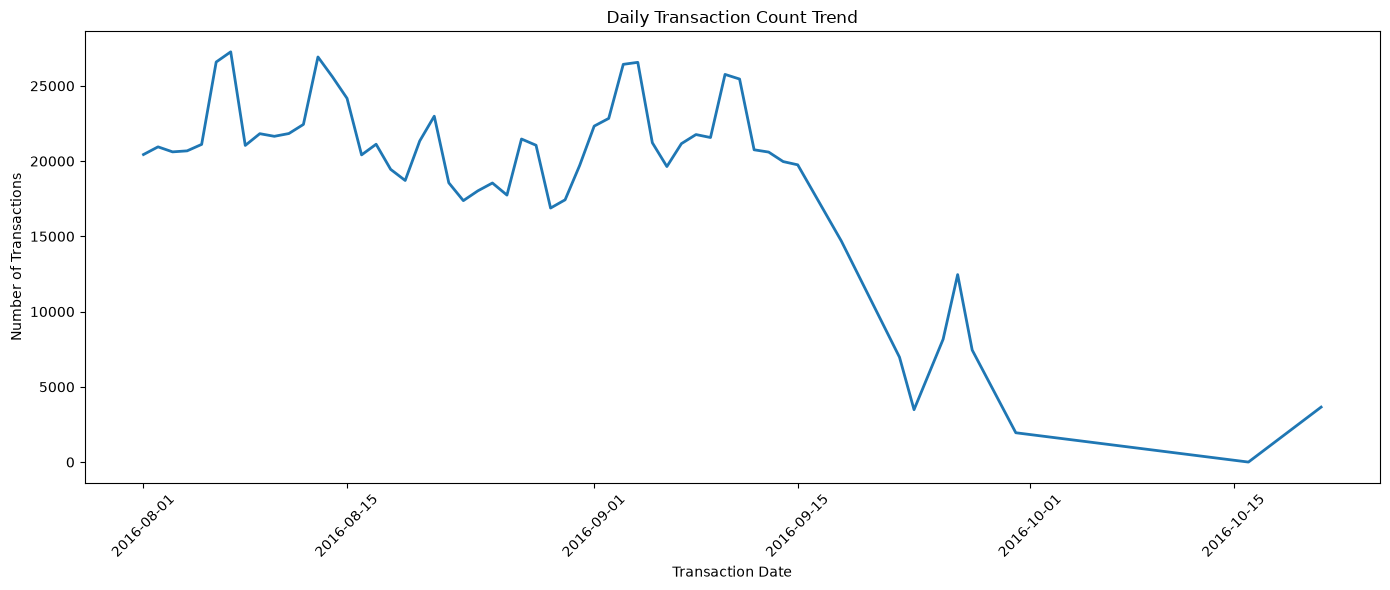

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\daily_transaction_count_trend.png


In [128]:
# ============================================
# CELL 60 — DAILY TRANSACTION COUNT TREND
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_transaction_trend["TransactionDate"],
    daily_transaction_trend["transaction_count"],
    linewidth=2
)

plt.title("Daily Transaction Count Trend")
plt.xlabel("Transaction Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
daily_transaction_count_path = (
    IMAGES_PATH / "daily_transaction_count_trend.png"
)

plt.savefig(
    daily_transaction_count_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(f"Chart berhasil disimpan di: {daily_transaction_count_path}")

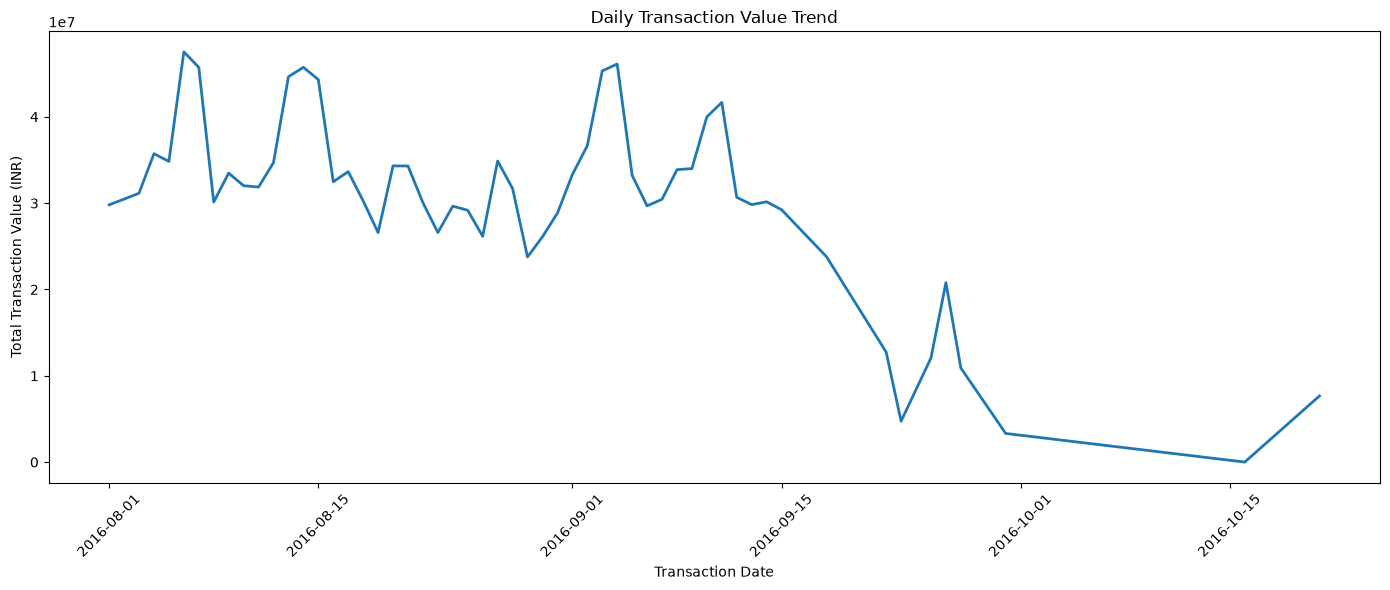

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\daily_transaction_value_trend.png


In [130]:
# ============================================
# CELL 61 — DAILY TRANSACTION VALUE TREND
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_transaction_trend["TransactionDate"],
    daily_transaction_trend["total_transaction_value"],
    linewidth=2
)

plt.title("Daily Transaction Value Trend")
plt.xlabel("Transaction Date")
plt.ylabel("Total Transaction Value (INR)")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
daily_transaction_value_path = (
    IMAGES_PATH / "daily_transaction_value_trend.png"
)

plt.savefig(
    daily_transaction_value_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{daily_transaction_value_path}"
)

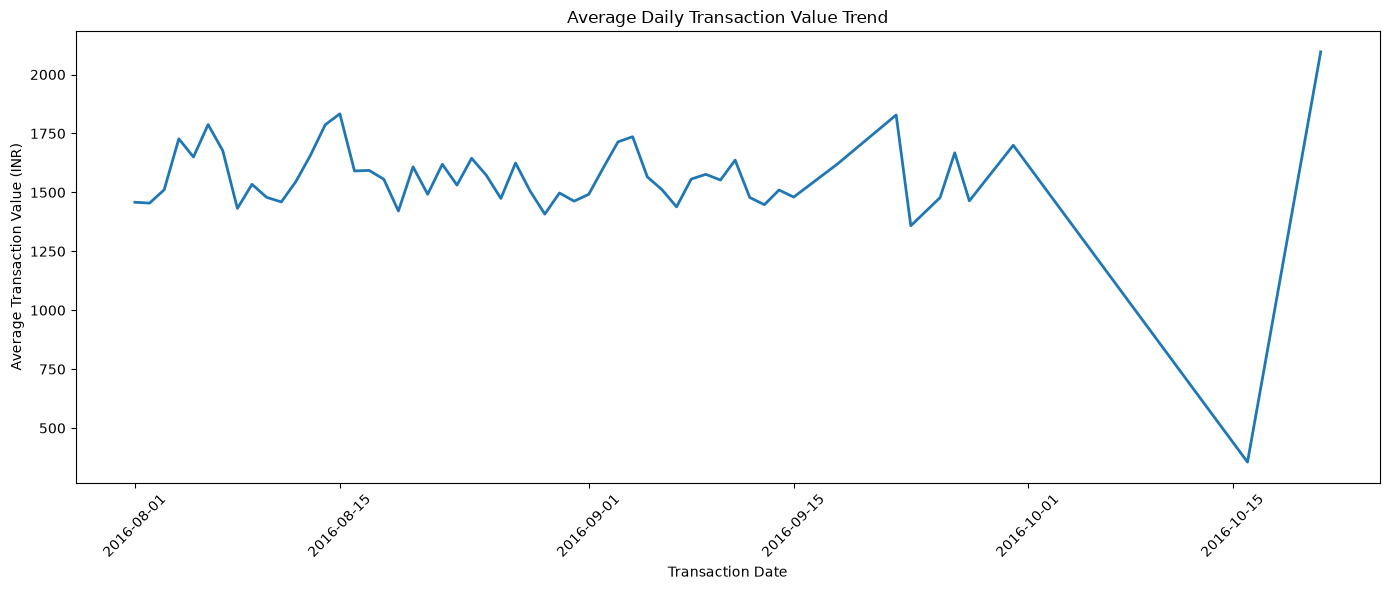

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\average_daily_transaction_value_trend.png


In [132]:
# ============================================
# CELL 62 — AVERAGE DAILY TRANSACTION VALUE TREND
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_transaction_trend["TransactionDate"],
    daily_transaction_trend["average_transaction_value"],
    linewidth=2
)

plt.title("Average Daily Transaction Value Trend")
plt.xlabel("Transaction Date")
plt.ylabel("Average Transaction Value (INR)")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
average_daily_transaction_value_path = (
    IMAGES_PATH / "average_daily_transaction_value_trend.png"
)

plt.savefig(
    average_daily_transaction_value_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{average_daily_transaction_value_path}"
)

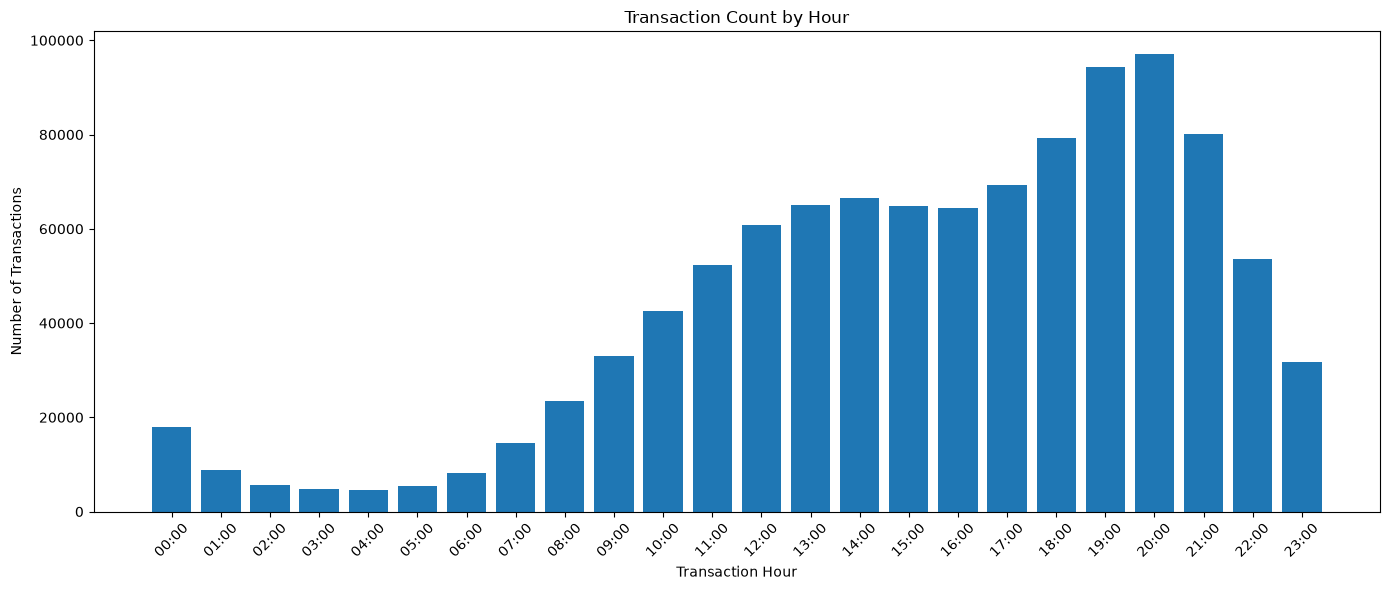

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\transaction_count_by_hour.png


In [134]:
# ============================================
# CELL 63 — TRANSACTION COUNT BY HOUR
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

hourly_transaction_count = (
    df_clean
    .groupby("TransactionHour", as_index=False)
    .agg(
        transaction_count=("TransactionID", "count")
    )
    .sort_values("TransactionHour")
)

plt.figure(figsize=(14, 6))

plt.bar(
    hourly_transaction_count["TransactionHour"],
    hourly_transaction_count["transaction_count"]
)

plt.title("Transaction Count by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Transactions")

plt.xticks(
    range(24),
    [f"{hour:02d}:00" for hour in range(24)],
    rotation=45
)

plt.tight_layout()

# Simpan chart
transaction_count_by_hour_path = (
    IMAGES_PATH / "transaction_count_by_hour.png"
)

plt.savefig(
    transaction_count_by_hour_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{transaction_count_by_hour_path}"
)

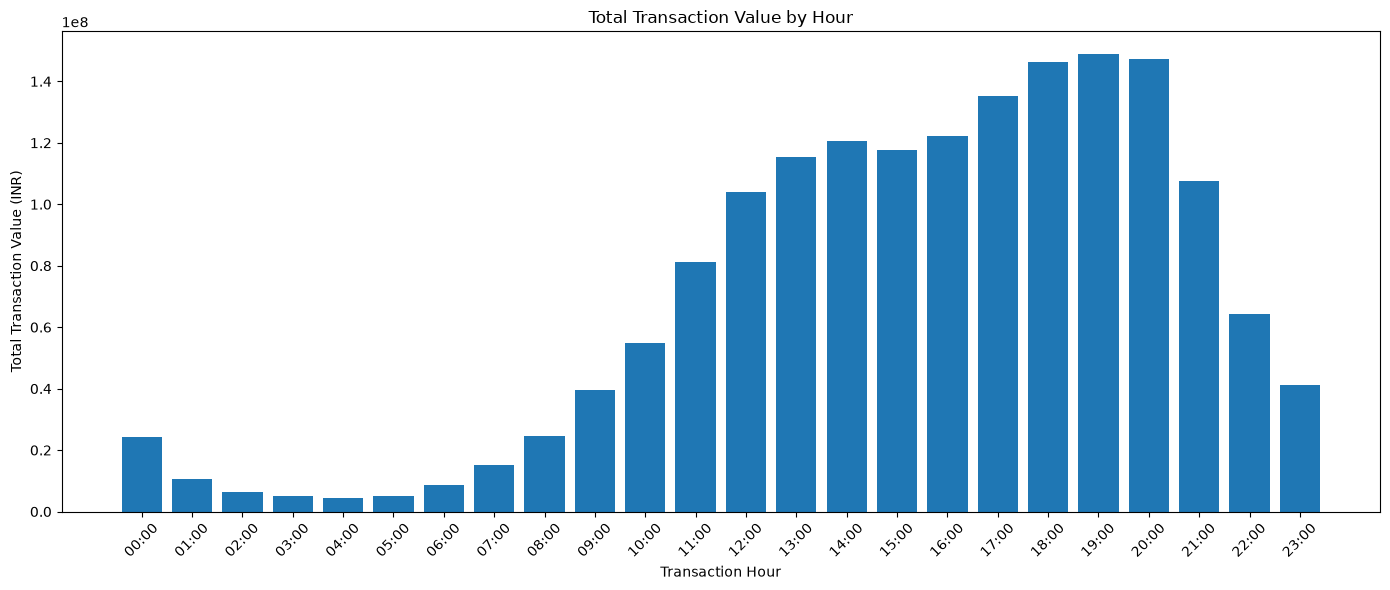

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\transaction_value_by_hour.png


In [136]:
# ============================================
# CELL 64 — TOTAL TRANSACTION VALUE BY HOUR
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

hourly_transaction_value = (
    df_clean
    .groupby("TransactionHour", as_index=False)
    .agg(
        total_transaction_value=(
            "TransactionAmount (INR)",
            "sum"
        )
    )
    .sort_values("TransactionHour")
)

plt.figure(figsize=(14, 6))

plt.bar(
    hourly_transaction_value["TransactionHour"],
    hourly_transaction_value["total_transaction_value"]
)

plt.title("Total Transaction Value by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Total Transaction Value (INR)")

plt.xticks(
    range(24),
    [f"{hour:02d}:00" for hour in range(24)],
    rotation=45
)

plt.tight_layout()

# Simpan chart
transaction_value_by_hour_path = (
    IMAGES_PATH / "transaction_value_by_hour.png"
)

plt.savefig(
    transaction_value_by_hour_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{transaction_value_by_hour_path}"
)

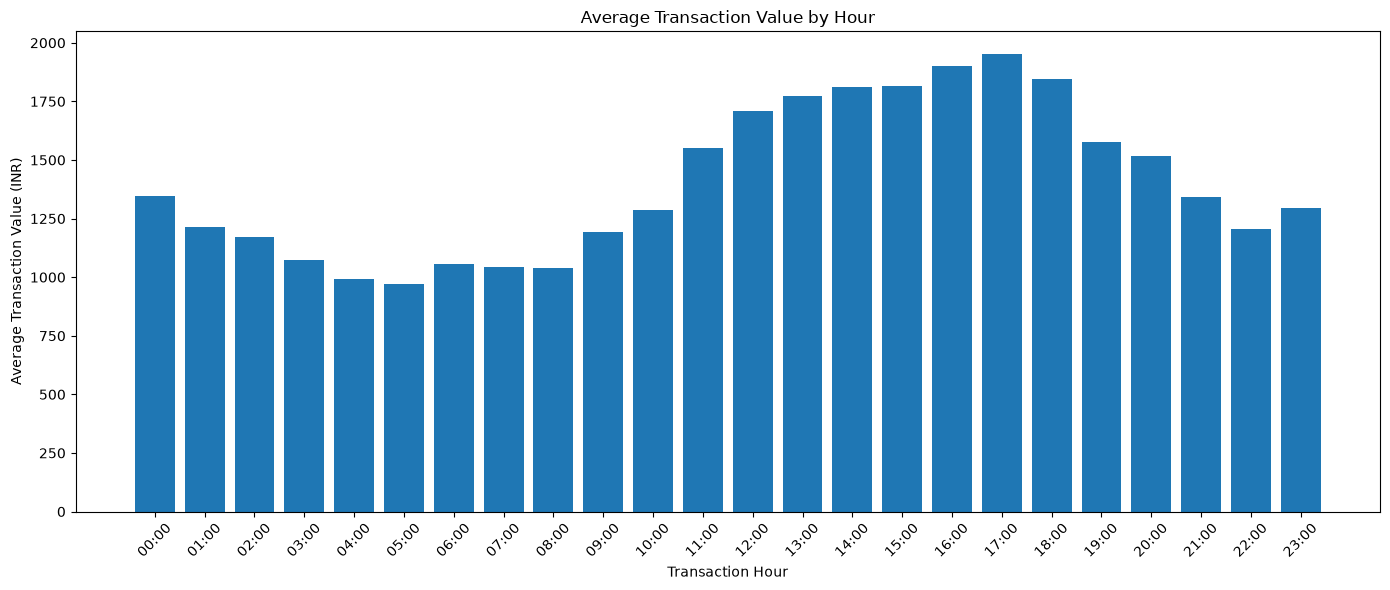

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\average_transaction_value_by_hour.png


In [138]:
# ============================================
# CELL 65 — AVERAGE TRANSACTION VALUE BY HOUR
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

hourly_average_transaction_value = (
    df_clean
    .groupby("TransactionHour", as_index=False)
    .agg(
        average_transaction_value=(
            "TransactionAmount (INR)",
            "mean"
        )
    )
    .sort_values("TransactionHour")
)

plt.figure(figsize=(14, 6))

plt.bar(
    hourly_average_transaction_value["TransactionHour"],
    hourly_average_transaction_value["average_transaction_value"]
)

plt.title("Average Transaction Value by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Average Transaction Value (INR)")

plt.xticks(
    range(24),
    [f"{hour:02d}:00" for hour in range(24)],
    rotation=45
)

plt.tight_layout()

# Simpan chart
average_transaction_value_by_hour_path = (
    IMAGES_PATH / "average_transaction_value_by_hour.png"
)

plt.savefig(
    average_transaction_value_by_hour_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{average_transaction_value_by_hour_path}"
)

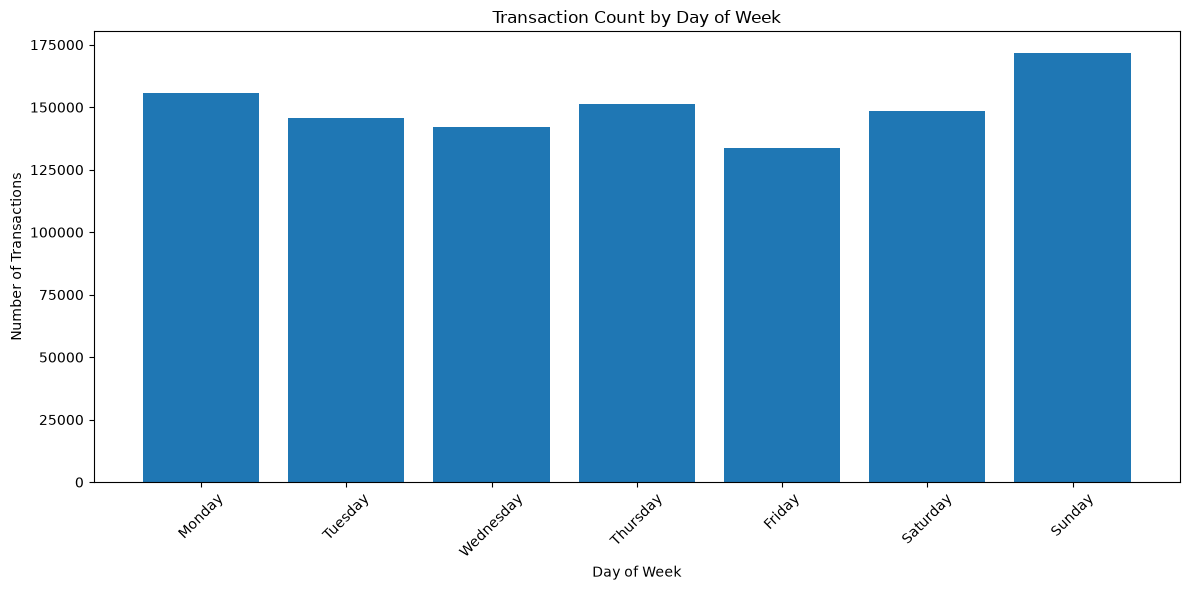

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\transaction_count_by_day_of_week.png


In [140]:
# ============================================
# CELL 66 — TRANSACTION COUNT BY DAY OF WEEK
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_count_chart = (
    df_clean
    .groupby("TransactionDayName", as_index=False)
    .agg(
        transaction_count=("TransactionID", "count")
    )
)

daily_count_chart["TransactionDayName"] = pd.Categorical(
    daily_count_chart["TransactionDayName"],
    categories=day_order,
    ordered=True
)

daily_count_chart = (
    daily_count_chart
    .sort_values("TransactionDayName")
)

plt.figure(figsize=(12, 6))

plt.bar(
    daily_count_chart["TransactionDayName"],
    daily_count_chart["transaction_count"]
)

plt.title("Transaction Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
transaction_count_by_day_path = (
    IMAGES_PATH / "transaction_count_by_day_of_week.png"
)

plt.savefig(
    transaction_count_by_day_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{transaction_count_by_day_path}"
)

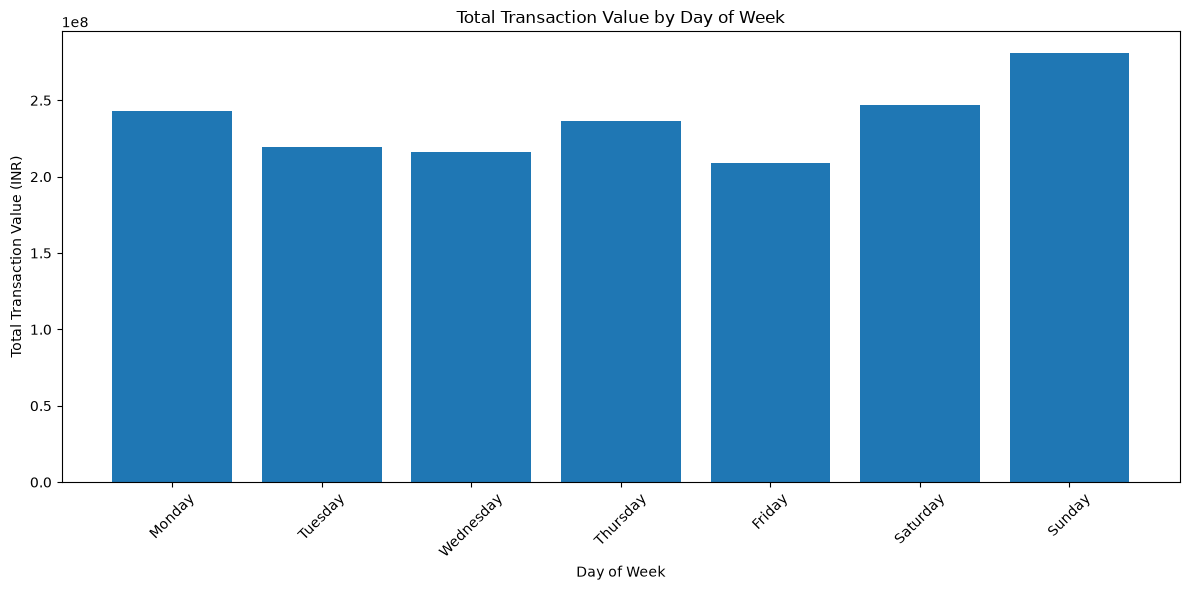

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\transaction_value_by_day_of_week.png


In [142]:
# ============================================
# CELL 67 — TOTAL TRANSACTION VALUE BY DAY OF WEEK
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_value_chart = (
    df_clean
    .groupby("TransactionDayName", as_index=False)
    .agg(
        total_transaction_value=(
            "TransactionAmount (INR)",
            "sum"
        )
    )
)

daily_value_chart["TransactionDayName"] = pd.Categorical(
    daily_value_chart["TransactionDayName"],
    categories=day_order,
    ordered=True
)

daily_value_chart = (
    daily_value_chart
    .sort_values("TransactionDayName")
)

plt.figure(figsize=(12, 6))

plt.bar(
    daily_value_chart["TransactionDayName"],
    daily_value_chart["total_transaction_value"]
)

plt.title("Total Transaction Value by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Transaction Value (INR)")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
transaction_value_by_day_path = (
    IMAGES_PATH / "transaction_value_by_day_of_week.png"
)

plt.savefig(
    transaction_value_by_day_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{transaction_value_by_day_path}"
)

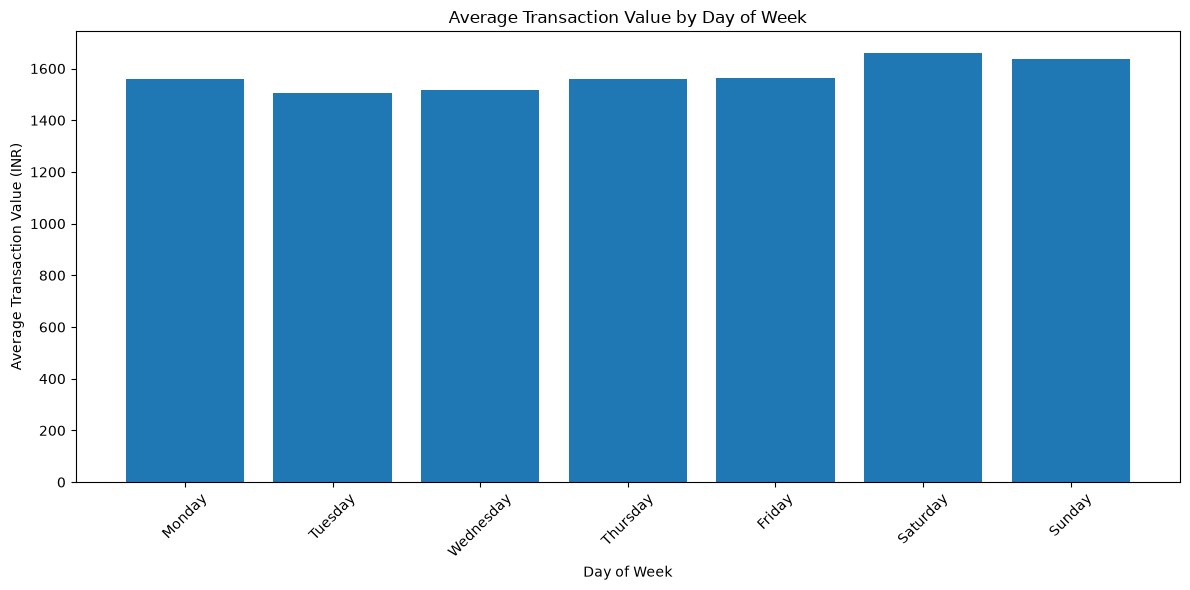

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\average_transaction_value_by_day_of_week.png


In [144]:
# ============================================
# CELL 68 — AVERAGE TRANSACTION VALUE BY DAY OF WEEK
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_average_chart = (
    df_clean
    .groupby("TransactionDayName", as_index=False)
    .agg(
        average_transaction_value=(
            "TransactionAmount (INR)",
            "mean"
        )
    )
)

daily_average_chart["TransactionDayName"] = pd.Categorical(
    daily_average_chart["TransactionDayName"],
    categories=day_order,
    ordered=True
)

daily_average_chart = (
    daily_average_chart
    .sort_values("TransactionDayName")
)

plt.figure(figsize=(12, 6))

plt.bar(
    daily_average_chart["TransactionDayName"],
    daily_average_chart["average_transaction_value"]
)

plt.title("Average Transaction Value by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Transaction Value (INR)")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
average_transaction_value_by_day_path = (
    IMAGES_PATH / "average_transaction_value_by_day_of_week.png"
)

plt.savefig(
    average_transaction_value_by_day_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{average_transaction_value_by_day_path}"
)

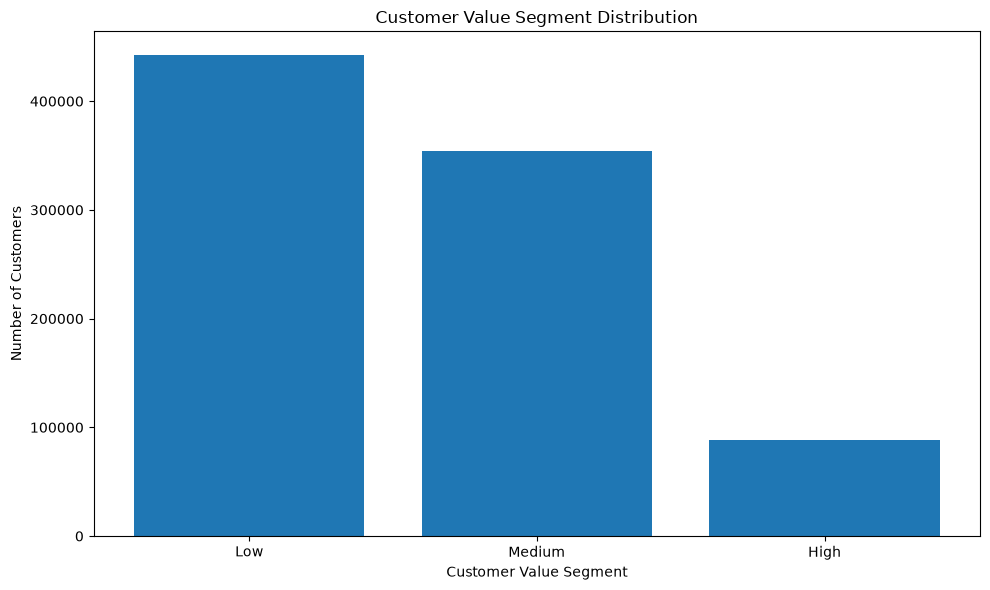

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\customer_value_segment_distribution.png


In [147]:
# ============================================
# CELL 69 — CUSTOMER VALUE SEGMENT DISTRIBUTION
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

segment_distribution_chart = (
    customer_value_segmentation
    .groupby(
        "customer_value_segment",
        observed=False
    )
    .agg(
        customer_count=("CustomerID", "nunique")
    )
    .reset_index()
)

segment_order = ["Low", "Medium", "High"]

segment_distribution_chart["customer_value_segment"] = pd.Categorical(
    segment_distribution_chart["customer_value_segment"],
    categories=segment_order,
    ordered=True
)

segment_distribution_chart = (
    segment_distribution_chart
    .sort_values("customer_value_segment")
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_distribution_chart["customer_value_segment"],
    segment_distribution_chart["customer_count"]
)

plt.title("Customer Value Segment Distribution")
plt.xlabel("Customer Value Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Simpan chart
customer_value_segment_path = (
    IMAGES_PATH / "customer_value_segment_distribution.png"
)

plt.savefig(
    customer_value_segment_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{customer_value_segment_path}"
)

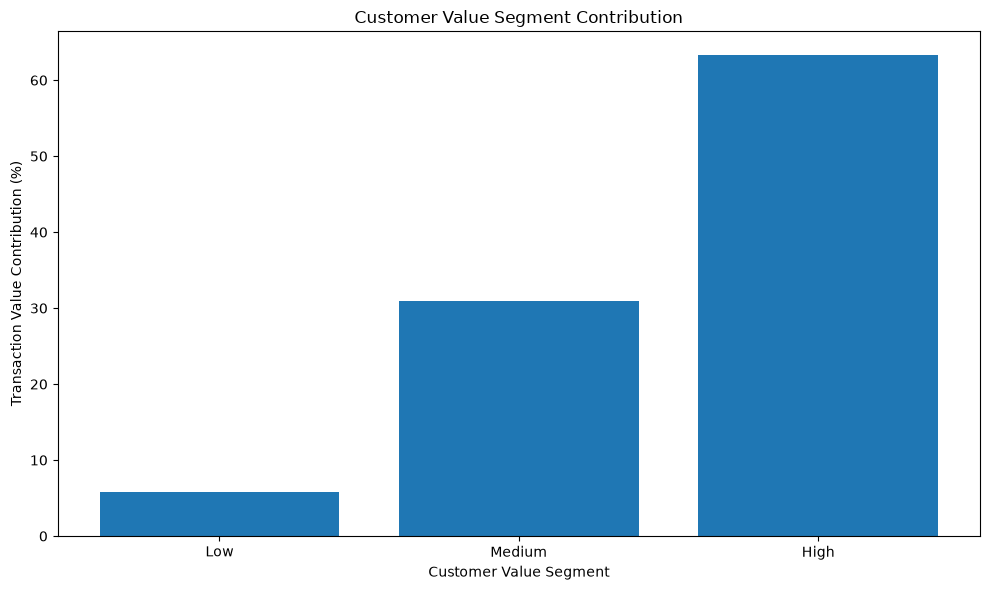

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\customer_value_segment_contribution.png


In [149]:
# ============================================
# CELL 70 — CUSTOMER VALUE CONTRIBUTION
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

segment_value_chart = (
    segment_contribution[
        [
            "customer_value_segment",
            "transaction_value_percentage"
        ]
    ]
    .copy()
)

segment_order = ["Low", "Medium", "High"]

segment_value_chart["customer_value_segment"] = pd.Categorical(
    segment_value_chart["customer_value_segment"],
    categories=segment_order,
    ordered=True
)

segment_value_chart = (
    segment_value_chart
    .sort_values("customer_value_segment")
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_value_chart["customer_value_segment"],
    segment_value_chart["transaction_value_percentage"]
)

plt.title("Customer Value Segment Contribution")
plt.xlabel("Customer Value Segment")
plt.ylabel("Transaction Value Contribution (%)")

plt.tight_layout()

# Simpan chart
customer_value_contribution_path = (
    IMAGES_PATH / "customer_value_segment_contribution.png"
)

plt.savefig(
    customer_value_contribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{customer_value_contribution_path}"
)

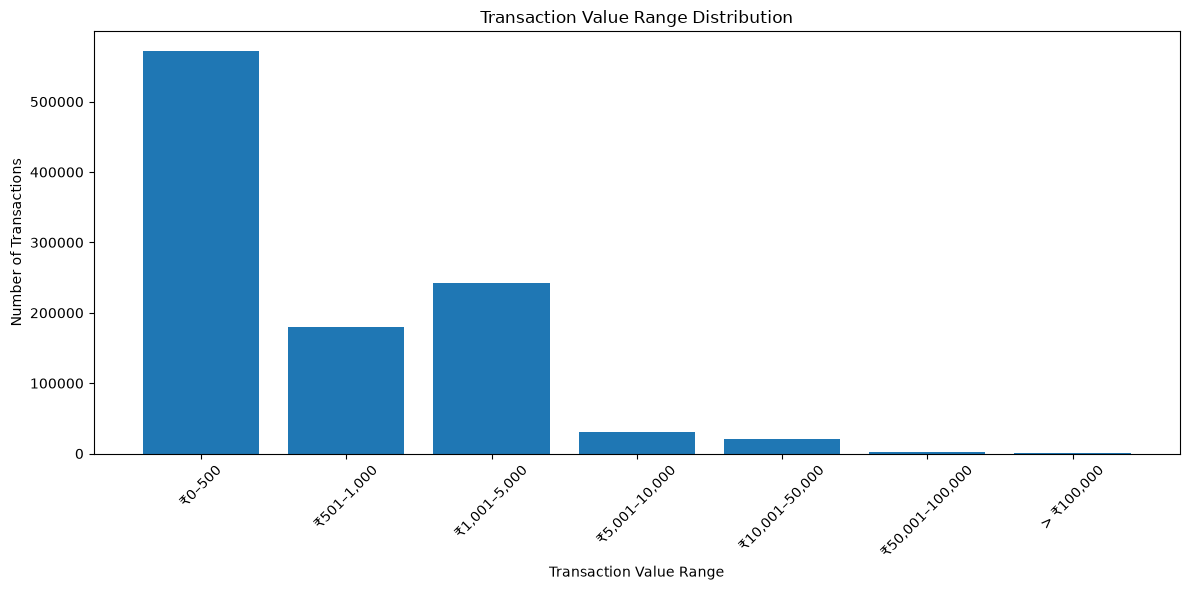

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\transaction_value_range_distribution.png


In [151]:
# ============================================
# CELL 71 — TRANSACTION VALUE RANGE DISTRIBUTION
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

transaction_range_chart = (
    transaction_value_range_summary[
        [
            "TransactionValueRange",
            "transaction_count"
        ]
    ]
    .copy()
)

plt.figure(figsize=(12, 6))

plt.bar(
    transaction_range_chart["TransactionValueRange"].astype(str),
    transaction_range_chart["transaction_count"]
)

plt.title("Transaction Value Range Distribution")
plt.xlabel("Transaction Value Range")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
transaction_value_range_path = (
    IMAGES_PATH / "transaction_value_range_distribution.png"
)

plt.savefig(
    transaction_value_range_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{transaction_value_range_path}"
)

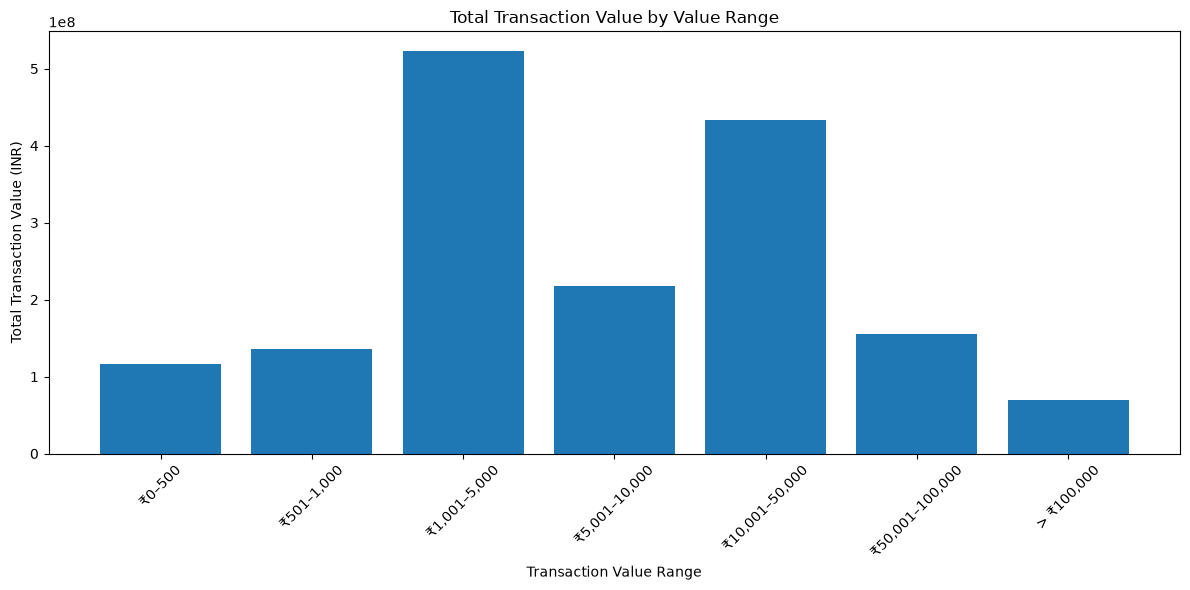

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\total_transaction_value_by_value_range.png


In [153]:
# ============================================
# CELL 72 — TOTAL TRANSACTION VALUE BY VALUE RANGE
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

transaction_range_value_chart = (
    transaction_value_range_summary[
        [
            "TransactionValueRange",
            "total_transaction_value"
        ]
    ]
    .copy()
)

plt.figure(figsize=(12, 6))

plt.bar(
    transaction_range_value_chart["TransactionValueRange"].astype(str),
    transaction_range_value_chart["total_transaction_value"]
)

plt.title("Total Transaction Value by Value Range")
plt.xlabel("Transaction Value Range")
plt.ylabel("Total Transaction Value (INR)")

plt.xticks(rotation=45)
plt.tight_layout()

# Simpan chart
transaction_value_by_range_path = (
    IMAGES_PATH / "total_transaction_value_by_value_range.png"
)

plt.savefig(
    transaction_value_by_range_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{transaction_value_by_range_path}"
)

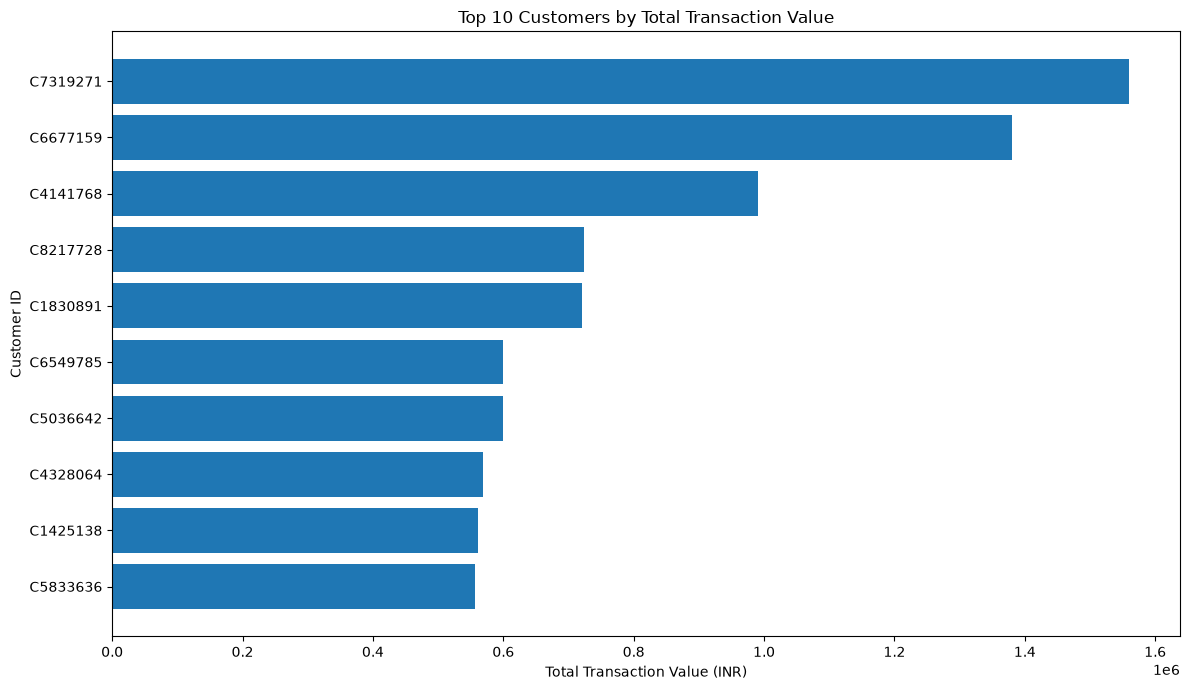

Chart berhasil ditampilkan.
Chart berhasil disimpan di: ..\images\top_10_customers_by_transaction_value.png


In [155]:
# ============================================
# CELL 73 — TOP 10 CUSTOMERS BY TRANSACTION VALUE
# ============================================

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

top_10_customers_chart = (
    customer_summary[
        [
            "CustomerID",
            "transaction_count",
            "total_transaction_value"
        ]
    ]
    .sort_values(
        "total_transaction_value",
        ascending=False
    )
    .head(10)
    .sort_values(
        "total_transaction_value",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_customers_chart["CustomerID"].astype(str),
    top_10_customers_chart["total_transaction_value"]
)

plt.title("Top 10 Customers by Total Transaction Value")
plt.xlabel("Total Transaction Value (INR)")
plt.ylabel("Customer ID")

plt.tight_layout()

# Simpan chart
top_10_customers_path = (
    IMAGES_PATH / "top_10_customers_by_transaction_value.png"
)

plt.savefig(
    top_10_customers_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart berhasil ditampilkan.")
print(
    f"Chart berhasil disimpan di: "
    f"{top_10_customers_path}"
)

In [157]:
# ============================================
# CELL 74 — SQL DATABASE SETUP
# ============================================

import sqlite3

DATABASE_PATH = Path("../data/processed/banking_transactions.db")

# Buat folder jika belum tersedia
DATABASE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Buat koneksi database
conn = sqlite3.connect(DATABASE_PATH)

print("=== SQL DATABASE SETUP ===")
print("Database berhasil dibuat/dibuka.")
print(f"Database path : {DATABASE_PATH}")
print(f"Koneksi aktif : {conn is not None}")

=== SQL DATABASE SETUP ===
Database berhasil dibuat/dibuka.
Database path : ..\data\processed\banking_transactions.db
Koneksi aktif : True


In [159]:
# ============================================
# CELL 75 — LOAD DATA KE DATABASE SQL
# ============================================

TABLE_NAME = "bank_transactions"

df_clean.to_sql(
    TABLE_NAME,
    conn,
    if_exists="replace",
    index=False
)

print("=== LOAD DATA TO SQL ===")
print("Data berhasil dimasukkan ke database.")
print(f"Nama tabel : {TABLE_NAME}")
print(f"Jumlah baris : {len(df_clean):,}")

=== LOAD DATA TO SQL ===
Data berhasil dimasukkan ke database.
Nama tabel : bank_transactions
Jumlah baris : 1,048,567


In [161]:
# ============================================
# CELL 76 — CEK TABEL DATABASE
# ============================================

cursor = conn.cursor()

# Cek daftar tabel
cursor.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
""")

tables = cursor.fetchall()

print("=== DATABASE TABLE CHECK ===")
print("Daftar tabel:")

for table in tables:
    print(f"- {table[0]}")

# Cek jumlah baris
cursor.execute("""
    SELECT COUNT(*)
    FROM bank_transactions;
""")

row_count = cursor.fetchone()[0]

print("\n=== ROW COUNT CHECK ===")
print(f"Jumlah baris dalam tabel : {row_count:,}")

# Status
if row_count == len(df_clean):
    print("PASS — Jumlah data SQL sesuai dengan dataframe.")
else:
    print("CHECK — Jumlah data SQL tidak sesuai.")

=== DATABASE TABLE CHECK ===
Daftar tabel:
- bank_transactions

=== ROW COUNT CHECK ===
Jumlah baris dalam tabel : 1,048,567
PASS — Jumlah data SQL sesuai dengan dataframe.


In [163]:
# ============================================
# CELL 77 — SQL: TOTAL CUSTOMERS & TRANSACTIONS
# ============================================

query_77 = """
SELECT
    COUNT(DISTINCT CustomerID) AS total_customers,
    COUNT(TransactionID) AS total_transactions
FROM bank_transactions;
"""

result_77 = pd.read_sql_query(
    query_77,
    conn
)

print("=== SQL ANALYSIS — TOTAL CUSTOMERS & TRANSACTIONS ===")
print(result_77.to_string(index=False))

=== SQL ANALYSIS — TOTAL CUSTOMERS & TRANSACTIONS ===
 total_customers  total_transactions
          884265             1048567


In [165]:
# ============================================
# CELL 78 — SQL: TRANSACTION VALUE ANALYSIS
# ============================================

query_78 = """
SELECT
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value,
    MIN("TransactionAmount (INR)") AS minimum_transaction_value,
    MAX("TransactionAmount (INR)") AS maximum_transaction_value
FROM bank_transactions;
"""

result_78 = pd.read_sql_query(
    query_78,
    conn
)

print("=== SQL ANALYSIS — TRANSACTION VALUE ===")

print(
    result_78.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format,
            "minimum_transaction_value": "₹{:,.2f}".format,
            "maximum_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TRANSACTION VALUE ===
total_transaction_value average_transaction_value minimum_transaction_value maximum_transaction_value
      ₹1,650,795,731.57                 ₹1,574.34                     ₹0.00             ₹1,560,034.99


In [167]:
# ============================================
# CELL 79 — SQL: CUSTOMER TRANSACTION SUMMARY
# ============================================

query_79 = """
SELECT
    CustomerID,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY CustomerID
ORDER BY total_transaction_value DESC
LIMIT 20;
"""

result_79 = pd.read_sql_query(
    query_79,
    conn
)

print("=== SQL ANALYSIS — TOP 20 CUSTOMERS BY TRANSACTION VALUE ===")

print(
    result_79.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TOP 20 CUSTOMERS BY TRANSACTION VALUE ===
CustomerID  transaction_count total_transaction_value average_transaction_value
  C7319271                  1           ₹1,560,034.99             ₹1,560,034.99
  C6677159                  1           ₹1,380,002.88             ₹1,380,002.88
  C4141768                  1             ₹991,132.22               ₹991,132.22
  C8217728                  2             ₹724,472.00               ₹362,236.00
  C1830891                  1             ₹720,001.16               ₹720,001.16
  C6549785                  1             ₹600,008.32               ₹600,008.32
  C5036642                  1             ₹600,003.45               ₹600,003.45
  C4328064                  1             ₹569,500.27               ₹569,500.27
  C1425138                  1             ₹561,001.00               ₹561,001.00
  C5833636                  1             ₹557,000.73               ₹557,000.73
  C3528755                  4             ₹550,972.34      

In [169]:
# ============================================
# CELL 80 — SQL: CUSTOMER TRANSACTION FREQUENCY
# ============================================

query_80 = """
SELECT
    transaction_count,
    COUNT(*) AS customer_count
FROM (
    SELECT
        CustomerID,
        COUNT(TransactionID) AS transaction_count
    FROM bank_transactions
    GROUP BY CustomerID
)
GROUP BY transaction_count
ORDER BY transaction_count;
"""

result_80 = pd.read_sql_query(
    query_80,
    conn
)

print("=== SQL ANALYSIS — CUSTOMER TRANSACTION FREQUENCY ===")

print(
    result_80.to_string(
        index=False
    )
)

=== SQL ANALYSIS — CUSTOMER TRANSACTION FREQUENCY ===
 transaction_count  customer_count
                 1          740653
                 2          124960
                 3           16789
                 4            1702
                 5             147
                 6              14


In [171]:
# ============================================
# CELL 81 — SQL: TRANSACTION ANALYSIS BY MONTH
# ============================================

query_81 = """
SELECT
    strftime('%Y', TransactionDate) AS transaction_year,
    strftime('%m', TransactionDate) AS transaction_month,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY
    strftime('%Y', TransactionDate),
    strftime('%m', TransactionDate)
ORDER BY
    transaction_year,
    transaction_month;
"""

result_81 = pd.read_sql_query(
    query_81,
    conn
)

print("=== SQL ANALYSIS — TRANSACTION BY MONTH ===")

print(
    result_81.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TRANSACTION BY MONTH ===
transaction_year transaction_month  transaction_count total_transaction_value average_transaction_value
            2016                08             653933       ₹1,030,599,493.84                 ₹1,576.00
            2016                09             390975         ₹612,531,219.10                 ₹1,566.68
            2016                10               3659           ₹7,665,018.63                 ₹2,094.84


In [173]:
# ============================================
# CELL 82 — SQL: TRANSACTION ANALYSIS BY HOUR
# ============================================

query_82 = """
SELECT
    CAST(
        substr(
            printf('%06d', TransactionTime),
            1,
            2
        ) AS INTEGER
    ) AS transaction_hour,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY transaction_hour
ORDER BY transaction_hour;
"""

result_82 = pd.read_sql_query(
    query_82,
    conn
)

print("=== SQL ANALYSIS — TRANSACTION BY HOUR ===")

print(
    result_82.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TRANSACTION BY HOUR ===
 transaction_hour  transaction_count total_transaction_value average_transaction_value
                0              17977          ₹24,220,958.52                 ₹1,347.33
                1               8851          ₹10,746,828.61                 ₹1,214.19
                2               5553           ₹6,505,162.85                 ₹1,171.47
                3               4720           ₹5,067,690.40                 ₹1,073.66
                4               4571           ₹4,536,081.19                   ₹992.36
                5               5359           ₹5,196,658.14                   ₹969.71
                6               8218           ₹8,667,636.23                 ₹1,054.71
                7              14579          ₹15,202,886.51                 ₹1,042.79
                8              23523          ₹24,470,804.41                 ₹1,040.29
                9              33098          ₹39,454,789.89                 ₹1,192.06


In [175]:
# ============================================
# CELL 83 — SQL: TRANSACTION ANALYSIS BY DAY OF WEEK
# ============================================

query_83 = """
SELECT
    CASE CAST(strftime('%w', TransactionDate) AS INTEGER)
        WHEN 0 THEN 'Sunday'
        WHEN 1 THEN 'Monday'
        WHEN 2 THEN 'Tuesday'
        WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday'
        WHEN 5 THEN 'Friday'
        WHEN 6 THEN 'Saturday'
    END AS transaction_day,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY strftime('%w', TransactionDate)
ORDER BY CAST(strftime('%w', TransactionDate) AS INTEGER);
"""

result_83 = pd.read_sql_query(
    query_83,
    conn
)

print("=== SQL ANALYSIS — TRANSACTION BY DAY OF WEEK ===")

print(
    result_83.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TRANSACTION BY DAY OF WEEK ===
transaction_day  transaction_count total_transaction_value average_transaction_value
         Sunday             171771         ₹281,118,298.22                 ₹1,636.59
         Monday             155525         ₹242,755,578.78                 ₹1,560.88
        Tuesday             145677         ₹219,535,076.16                 ₹1,507.00
      Wednesday             142252         ₹215,891,067.37                 ₹1,517.67
       Thursday             151331         ₹236,185,271.18                 ₹1,560.72
         Friday             133505         ₹208,642,653.59                 ₹1,562.81
       Saturday             148506         ₹246,667,786.27                 ₹1,661.00


In [177]:
# ============================================
# CELL 84 — SQL: CUSTOMER VALUE SEGMENT
# ============================================

query_84 = """
SELECT
    customer_value_segment,
    COUNT(*) AS customer_count,
    SUM(total_transaction_value) AS total_transaction_value,
    AVG(total_transaction_value) AS average_customer_value
FROM (
    SELECT
        CustomerID,
        SUM("TransactionAmount (INR)") AS total_transaction_value,
        CASE
            WHEN SUM("TransactionAmount (INR)") <= 536.80
                THEN 'Low'
            WHEN SUM("TransactionAmount (INR)") <= 3577.00
                THEN 'Medium'
            ELSE 'High'
        END AS customer_value_segment
    FROM bank_transactions
    GROUP BY CustomerID
)
GROUP BY customer_value_segment
ORDER BY
    CASE customer_value_segment
        WHEN 'Low' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'High' THEN 3
    END;
"""

result_84 = pd.read_sql_query(
    query_84,
    conn
)

print("=== SQL ANALYSIS — CUSTOMER VALUE SEGMENT ===")

print(
    result_84.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_customer_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — CUSTOMER VALUE SEGMENT ===
customer_value_segment  customer_count total_transaction_value average_customer_value
                   Low          442133          ₹96,242,651.44                ₹217.68
                Medium          353710         ₹510,164,137.51              ₹1,442.32
                  High           88422       ₹1,044,388,942.62             ₹11,811.42


In [181]:
# ============================================
# CELL 85 — SQL: CUSTOMER SEGMENT CONTRIBUTION
# ============================================

query_85 = """
WITH customer_segments AS (
    SELECT
        CustomerID,
        SUM("TransactionAmount (INR)") AS total_transaction_value,
        CASE
            WHEN SUM("TransactionAmount (INR)") <= 536.80
                THEN 'Low'
            WHEN SUM("TransactionAmount (INR)") <= 3577.00
                THEN 'Medium'
            ELSE 'High'
        END AS customer_value_segment
    FROM bank_transactions
    GROUP BY CustomerID
),

segment_summary AS (
    SELECT
        customer_value_segment,
        COUNT(*) AS customer_count,
        SUM(total_transaction_value) AS total_transaction_value
    FROM customer_segments
    GROUP BY customer_value_segment
),

overall_summary AS (
    SELECT
        COUNT(*) AS total_customers,
        SUM(total_transaction_value) AS overall_transaction_value
    FROM customer_segments
)

SELECT
    s.customer_value_segment,
    s.customer_count,
    ROUND(
        s.customer_count * 100.0 / o.total_customers,
        2
    ) AS customer_percentage,
    s.total_transaction_value,
    ROUND(
        s.total_transaction_value * 100.0
        / o.overall_transaction_value,
        2
    ) AS transaction_value_percentage
FROM segment_summary s
CROSS JOIN overall_summary o
ORDER BY
    CASE s.customer_value_segment
        WHEN 'Low' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'High' THEN 3
    END;
"""

result_85 = pd.read_sql_query(
    query_85,
    conn
)

print("=== SQL ANALYSIS — CUSTOMER SEGMENT CONTRIBUTION ===")

print(
    result_85.to_string(
        index=False,
        formatters={
            "customer_percentage": "{:.2f}%".format,
            "total_transaction_value": "₹{:,.2f}".format,
            "transaction_value_percentage": "{:.2f}%".format
        }
    )
)

=== SQL ANALYSIS — CUSTOMER SEGMENT CONTRIBUTION ===
customer_value_segment  customer_count customer_percentage total_transaction_value transaction_value_percentage
                   Low          442133              50.00%          ₹96,242,651.44                        5.83%
                Medium          353710              40.00%         ₹510,164,137.51                       30.90%
                  High           88422              10.00%       ₹1,044,388,942.62                       63.27%


In [183]:
# ============================================
# CELL 86 — SQL: TOP CUSTOMER BY FREQUENCY
# ============================================

query_86 = """
SELECT
    CustomerID,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY CustomerID
ORDER BY
    transaction_count DESC,
    total_transaction_value DESC
LIMIT 20;
"""

result_86 = pd.read_sql_query(
    query_86,
    conn
)

print("=== SQL ANALYSIS — TOP CUSTOMERS BY TRANSACTION FREQUENCY ===")

print(
    result_86.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TOP CUSTOMERS BY TRANSACTION FREQUENCY ===
CustomerID  transaction_count total_transaction_value average_transaction_value
  C1113684                  6              ₹37,873.00                 ₹6,312.17
  C7537344                  6              ₹21,597.50                 ₹3,599.58
  C3226689                  6              ₹14,758.39                 ₹2,459.73
  C4513786                  6              ₹12,800.00                 ₹2,133.33
  C4327447                  6              ₹12,027.00                 ₹2,004.50
  C4021562                  6               ₹9,796.03                 ₹1,632.67
  C5531319                  6               ₹8,503.00                 ₹1,417.17
  C6624352                  6               ₹8,375.74                 ₹1,395.96
  C6222360                  6               ₹5,825.00                   ₹970.83
  C5418253                  6               ₹5,722.78                   ₹953.80
  C1736254                  6               ₹5,554.50     

In [185]:
# ============================================
# CELL 87 — SQL: TRANSACTION VALUE RANGE
# ============================================

query_87 = """
SELECT
    CASE
        WHEN "TransactionAmount (INR)" <= 500
            THEN '₹0–500'
        WHEN "TransactionAmount (INR)" <= 1000
            THEN '₹501–1,000'
        WHEN "TransactionAmount (INR)" <= 5000
            THEN '₹1,001–5,000'
        WHEN "TransactionAmount (INR)" <= 10000
            THEN '₹5,001–10,000'
        WHEN "TransactionAmount (INR)" <= 50000
            THEN '₹10,001–50,000'
        WHEN "TransactionAmount (INR)" <= 100000
            THEN '₹50,001–100,000'
        ELSE '> ₹100,000'
    END AS transaction_value_range,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY transaction_value_range
ORDER BY
    CASE transaction_value_range
        WHEN '₹0–500' THEN 1
        WHEN '₹501–1,000' THEN 2
        WHEN '₹1,001–5,000' THEN 3
        WHEN '₹5,001–10,000' THEN 4
        WHEN '₹10,001–50,000' THEN 5
        WHEN '₹50,001–100,000' THEN 6
        WHEN '> ₹100,000' THEN 7
    END;
"""

result_87 = pd.read_sql_query(
    query_87,
    conn
)

print("=== SQL ANALYSIS — TRANSACTION VALUE RANGE ===")

print(
    result_87.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TRANSACTION VALUE RANGE ===
transaction_value_range  transaction_count total_transaction_value average_transaction_value
                 ₹0–500             571386         ₹116,260,176.08                   ₹203.47
             ₹501–1,000             180212         ₹135,334,047.47                   ₹750.97
           ₹1,001–5,000             242182         ₹522,407,983.51                 ₹2,157.09
          ₹5,001–10,000              30971         ₹217,770,949.76                 ₹7,031.45
         ₹10,001–50,000              21436         ₹433,748,513.57                ₹20,234.58
        ₹50,001–100,000               1996         ₹155,070,939.27                ₹77,690.85
             > ₹100,000                384          ₹70,203,121.91               ₹182,820.63


In [187]:
# ============================================
# CELL 88 — SQL: DAILY TRANSACTION PERFORMANCE
# ============================================

query_88 = """
SELECT
    TransactionDate AS transaction_date,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY TransactionDate
ORDER BY TransactionDate;
"""

result_88 = pd.read_sql_query(
    query_88,
    conn
)

print("=== SQL ANALYSIS — DAILY TRANSACTION PERFORMANCE ===")

print(
    result_88.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — DAILY TRANSACTION PERFORMANCE ===
   transaction_date  transaction_count total_transaction_value average_transaction_value
2016-08-01 00:00:00              20438          ₹29,801,816.34                 ₹1,458.16
2016-08-02 00:00:00              20948          ₹30,467,503.29                 ₹1,454.43
2016-08-03 00:00:00              20615          ₹31,149,483.67                 ₹1,511.01
2016-08-04 00:00:00              20682          ₹35,722,718.64                 ₹1,727.24
2016-08-05 00:00:00              21112          ₹34,833,933.12                 ₹1,649.96
2016-08-06 00:00:00              26585          ₹47,527,227.82                 ₹1,787.75
2016-08-07 00:00:00              27261          ₹45,727,772.63                 ₹1,677.41
2016-08-08 00:00:00              21042          ₹30,129,433.64                 ₹1,431.87
2016-08-09 00:00:00              21823          ₹33,479,570.48                 ₹1,534.14
2016-08-10 00:00:00              21649          ₹32,016,3

In [189]:
# ============================================
# CELL 89 — SQL: PEAK TRANSACTION DAYS
# ============================================

query_89 = """
SELECT
    TransactionDate AS transaction_date,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY TransactionDate
ORDER BY transaction_count DESC
LIMIT 10;
"""

result_89 = pd.read_sql_query(
    query_89,
    conn
)

print("=== SQL ANALYSIS — PEAK TRANSACTION DAYS ===")

print(
    result_89.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — PEAK TRANSACTION DAYS ===
   transaction_date  transaction_count total_transaction_value average_transaction_value
2016-08-07 00:00:00              27261          ₹45,727,772.63                 ₹1,677.41
2016-08-13 00:00:00              26921          ₹44,645,472.34                 ₹1,658.39
2016-08-06 00:00:00              26585          ₹47,527,227.82                 ₹1,787.75
2016-09-04 00:00:00              26564          ₹46,118,447.52                 ₹1,736.13
2016-09-03 00:00:00              26431          ₹45,312,089.56                 ₹1,714.35
2016-09-10 00:00:00              25761          ₹39,988,234.58                 ₹1,552.28
2016-08-14 00:00:00              25596          ₹45,732,820.10                 ₹1,786.72
2016-09-11 00:00:00              25454          ₹41,668,308.96                 ₹1,637.00
2016-08-15 00:00:00              24171          ₹44,313,092.06                 ₹1,833.32
2016-08-21 00:00:00              22986          ₹34,301,751.22   

In [191]:
# ============================================
# CELL 90 — SQL: TOP DAYS BY TRANSACTION VALUE
# ============================================

query_90 = """
SELECT
    TransactionDate AS transaction_date,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY TransactionDate
ORDER BY total_transaction_value DESC
LIMIT 10;
"""

result_90 = pd.read_sql_query(
    query_90,
    conn
)

print("=== SQL ANALYSIS — TOP DAYS BY TRANSACTION VALUE ===")

print(
    result_90.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TOP DAYS BY TRANSACTION VALUE ===
   transaction_date  transaction_count total_transaction_value average_transaction_value
2016-08-06 00:00:00              26585          ₹47,527,227.82                 ₹1,787.75
2016-09-04 00:00:00              26564          ₹46,118,447.52                 ₹1,736.13
2016-08-14 00:00:00              25596          ₹45,732,820.10                 ₹1,786.72
2016-08-07 00:00:00              27261          ₹45,727,772.63                 ₹1,677.41
2016-09-03 00:00:00              26431          ₹45,312,089.56                 ₹1,714.35
2016-08-13 00:00:00              26921          ₹44,645,472.34                 ₹1,658.39
2016-08-15 00:00:00              24171          ₹44,313,092.06                 ₹1,833.32
2016-09-11 00:00:00              25454          ₹41,668,308.96                 ₹1,637.00
2016-09-10 00:00:00              25761          ₹39,988,234.58                 ₹1,552.28
2016-09-02 00:00:00              22839          ₹36,649,8

In [193]:
# ============================================
# CELL 91 — SQL: TRANSACTION ACTIVITY BY TIME PERIOD
# ============================================

query_91 = """
SELECT
    CASE
        WHEN CAST(substr(printf('%06d', TransactionTime), 1, 2) AS INTEGER)
             BETWEEN 0 AND 5
            THEN '00:00–05:59'
        WHEN CAST(substr(printf('%06d', TransactionTime), 1, 2) AS INTEGER)
             BETWEEN 6 AND 11
            THEN '06:00–11:59'
        WHEN CAST(substr(printf('%06d', TransactionTime), 1, 2) AS INTEGER)
             BETWEEN 12 AND 17
            THEN '12:00–17:59'
        ELSE '18:00–23:59'
    END AS time_period,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY time_period
ORDER BY
    CASE time_period
        WHEN '00:00–05:59' THEN 1
        WHEN '06:00–11:59' THEN 2
        WHEN '12:00–17:59' THEN 3
        WHEN '18:00–23:59' THEN 4
    END;
"""

result_91 = pd.read_sql_query(
    query_91,
    conn
)

print("=== SQL ANALYSIS — TRANSACTION ACTIVITY BY TIME PERIOD ===")

print(
    result_91.to_string(
        index=False,
        formatters={
            "total_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TRANSACTION ACTIVITY BY TIME PERIOD ===
time_period  transaction_count total_transaction_value average_transaction_value
00:00–05:59              47031          ₹56,273,379.71                 ₹1,196.52
06:00–11:59             174473         ₹223,807,919.22                 ₹1,282.77
12:00–17:59             390884         ₹715,112,023.53                 ₹1,829.47
18:00–23:59             436179         ₹655,602,409.11                 ₹1,503.06


In [195]:
# ============================================
# CELL 92 — SQL: TRANSACTION VALUE DISTRIBUTION
# ============================================

query_92 = """
WITH ordered_transactions AS (
    SELECT
        "TransactionAmount (INR)" AS transaction_amount,
        ROW_NUMBER() OVER (
            ORDER BY "TransactionAmount (INR)"
        ) AS row_number,
        COUNT(*) OVER () AS total_rows
    FROM bank_transactions
)

SELECT
    MIN(transaction_amount) AS minimum_transaction_value,
    MAX(transaction_amount) AS maximum_transaction_value,
    AVG(transaction_amount) AS average_transaction_value,
    (
        SELECT AVG(transaction_amount)
        FROM ordered_transactions
        WHERE row_number IN (
            CAST((total_rows + 1) / 2 AS INTEGER),
            CAST((total_rows + 2) / 2 AS INTEGER)
        )
    ) AS median_transaction_value
FROM ordered_transactions;
"""

result_92 = pd.read_sql_query(
    query_92,
    conn
)

print("=== SQL ANALYSIS — TRANSACTION VALUE DISTRIBUTION ===")

print(
    result_92.to_string(
        index=False,
        formatters={
            "minimum_transaction_value": "₹{:,.2f}".format,
            "maximum_transaction_value": "₹{:,.2f}".format,
            "average_transaction_value": "₹{:,.2f}".format,
            "median_transaction_value": "₹{:,.2f}".format
        }
    )
)

=== SQL ANALYSIS — TRANSACTION VALUE DISTRIBUTION ===
minimum_transaction_value maximum_transaction_value average_transaction_value median_transaction_value
                    ₹0.00             ₹1,560,034.99                 ₹1,574.34                  ₹459.03


In [197]:
# ============================================
# CELL 93 — BUSINESS INSIGHTS
# ============================================

business_insights = [
    {
        "Insight": "Customer Base",
        "Finding": (
            f"Dataset mencatat {total_customers:,} customer dengan "
            f"{total_transactions:,} transaksi."
        )
    },
    {
        "Insight": "Customer Transaction Frequency",
        "Finding": (
            f"Rata-rata transaksi per customer adalah "
            f"{average_transactions_per_customer:.2f}, dengan median 1 transaksi. "
            "Hal ini menunjukkan bahwa sebagian besar customer tercatat "
            "melakukan transaksi dalam jumlah terbatas."
        )
    },
    {
        "Insight": "High-Value Customer Contribution",
        "Finding": (
            "Segmen High hanya mencakup sekitar 10% customer, tetapi "
            "berkontribusi sekitar 63.27% dari total nilai transaksi."
        )
    },
    {
        "Insight": "Transaction Value Distribution",
        "Finding": (
            f"Median nilai transaksi sebesar ₹{median_transaction_value:,.2f} "
            f"lebih rendah dibandingkan rata-rata ₹{average_transaction_value:,.2f}, "
            "yang menunjukkan adanya transaksi bernilai besar yang meningkatkan "
            "nilai rata-rata."
        )
    },
    {
        "Insight": "Transaction Value Range",
        "Finding": (
            "Rentang ₹1,001–5,000 memiliki total nilai transaksi terbesar, "
            "sedangkan transaksi ₹0–500 memiliki jumlah transaksi terbanyak."
        )
    },
    {
        "Insight": "Peak Transaction Period",
        "Finding": (
            "Periode 18:00–23:59 memiliki jumlah transaksi terbanyak, "
            "sedangkan periode 12:00–17:59 menghasilkan total nilai transaksi "
            "tertinggi."
        )
    },
    {
        "Insight": "Day of Week",
        "Finding": (
            "Sunday memiliki jumlah transaksi dan total nilai transaksi "
            "tertinggi dibandingkan hari lainnya dalam dataset."
        )
    },
    {
        "Insight": "Data Coverage",
        "Finding": (
            "Dataset mencakup periode 1 Agustus hingga 21 Oktober 2016 "
            "dengan 55 tanggal transaksi. Beberapa tanggal tidak memiliki "
            "data transaksi, sehingga perubahan aktivitas pada akhir periode "
            "perlu diinterpretasikan dengan hati-hati."
        )
    }
]

business_insights_df = pd.DataFrame(business_insights)

print("=== BUSINESS INSIGHTS ===")
print()

for i, row in business_insights_df.iterrows():
    print(f"{i + 1}. {row['Insight']}")
    print(f"   {row['Finding']}")
    print()

=== BUSINESS INSIGHTS ===

1. Customer Base
   Dataset mencatat 884,265 customer dengan 1,048,567 transaksi.

2. Customer Transaction Frequency
   Rata-rata transaksi per customer adalah 1.19, dengan median 1 transaksi. Hal ini menunjukkan bahwa sebagian besar customer tercatat melakukan transaksi dalam jumlah terbatas.

3. High-Value Customer Contribution
   Segmen High hanya mencakup sekitar 10% customer, tetapi berkontribusi sekitar 63.27% dari total nilai transaksi.

4. Transaction Value Distribution
   Median nilai transaksi sebesar ₹459.03 lebih rendah dibandingkan rata-rata ₹1,574.34, yang menunjukkan adanya transaksi bernilai besar yang meningkatkan nilai rata-rata.

5. Transaction Value Range
   Rentang ₹1,001–5,000 memiliki total nilai transaksi terbesar, sedangkan transaksi ₹0–500 memiliki jumlah transaksi terbanyak.

6. Peak Transaction Period
   Periode 18:00–23:59 memiliki jumlah transaksi terbanyak, sedangkan periode 12:00–17:59 menghasilkan total nilai transaksi terting

In [199]:
# ============================================
# CELL 94 — BUSINESS RECOMMENDATIONS
# ============================================

business_recommendations = [
    {
        "Recommendation": "Customer Retention",
        "Action": (
            "Fokus mempertahankan customer dengan nilai transaksi tinggi "
            "melalui program relationship management dan layanan yang lebih personal."
        ),
        "Basis Insight": (
            "Segmen High hanya sekitar 10% customer tetapi menyumbang "
            "63.27% dari total nilai transaksi."
        )
    },
    {
        "Recommendation": "Customer Engagement",
        "Action": (
            "Dorong peningkatan frekuensi transaksi melalui program engagement "
            "dan aktivitas yang mendorong customer melakukan transaksi kembali."
        ),
        "Basis Insight": (
            "Median transaksi per customer adalah 1 transaksi dan rata-rata "
            "transaksi per customer sebesar 1.19."
        )
    },
    {
        "Recommendation": "Transaction Timing",
        "Action": (
            "Prioritaskan monitoring dan kesiapan layanan pada periode "
            "12:00–17:59 dan 18:00–23:59 karena aktivitas transaksi relatif tinggi."
        ),
        "Basis Insight": (
            "Periode 18:00–23:59 memiliki jumlah transaksi tertinggi, "
            "sedangkan 12:00–17:59 memiliki total nilai transaksi tertinggi."
        )
    },
    {
        "Recommendation": "Weekend Transaction Activity",
        "Action": (
            "Evaluasi peluang program atau aktivitas layanan pada akhir pekan, "
            "khususnya Sunday, untuk mempertahankan tingginya aktivitas transaksi."
        ),
        "Basis Insight": (
            "Sunday memiliki jumlah transaksi dan total nilai transaksi "
            "tertinggi berdasarkan hari dalam dataset."
        )
    },
    {
        "Recommendation": "Transaction Value Monitoring",
        "Action": (
            "Gunakan segmentasi nilai transaksi untuk membantu monitoring "
            "transaksi bernilai tinggi dan memahami kontribusinya terhadap "
            "total transaction value."
        ),
        "Basis Insight": (
            "Sebagian besar transaksi berada pada nilai rendah, tetapi "
            "transaksi bernilai tinggi memberikan kontribusi besar terhadap "
            "total nilai transaksi."
        )
    },
    {
        "Recommendation": "Data Monitoring",
        "Action": (
            "Perhatikan kelengkapan data tanggal sebelum menggunakan data "
            "untuk evaluasi tren bulanan atau perbandingan antarperiode."
        ),
        "Basis Insight": (
            "Dataset hanya memiliki 55 tanggal transaksi dalam periode "
            "1 Agustus–21 Oktober 2016 dan beberapa tanggal tidak memiliki data."
        )
    }
]

business_recommendations_df = pd.DataFrame(
    business_recommendations
)

print("=== BUSINESS RECOMMENDATIONS ===")
print()

for i, row in business_recommendations_df.iterrows():
    print(f"{i + 1}. {row['Recommendation']}")
    print(f"   Action        : {row['Action']}")
    print(f"   Basis Insight : {row['Basis Insight']}")
    print()

=== BUSINESS RECOMMENDATIONS ===

1. Customer Retention
   Action        : Fokus mempertahankan customer dengan nilai transaksi tinggi melalui program relationship management dan layanan yang lebih personal.
   Basis Insight : Segmen High hanya sekitar 10% customer tetapi menyumbang 63.27% dari total nilai transaksi.

2. Customer Engagement
   Action        : Dorong peningkatan frekuensi transaksi melalui program engagement dan aktivitas yang mendorong customer melakukan transaksi kembali.
   Basis Insight : Median transaksi per customer adalah 1 transaksi dan rata-rata transaksi per customer sebesar 1.19.

3. Transaction Timing
   Action        : Prioritaskan monitoring dan kesiapan layanan pada periode 12:00–17:59 dan 18:00–23:59 karena aktivitas transaksi relatif tinggi.
   Basis Insight : Periode 18:00–23:59 memiliki jumlah transaksi tertinggi, sedangkan 12:00–17:59 memiliki total nilai transaksi tertinggi.

4. Weekend Transaction Activity
   Action        : Evaluasi peluang progra

In [201]:
# ============================================
# CELL 95 — DASHBOARD KPI
# ============================================

dashboard_kpi = {
    "Total Customers": df_clean["CustomerID"].nunique(),
    "Total Transactions": df_clean["TransactionID"].nunique(),
    "Total Transaction Value": df_clean["TransactionAmount (INR)"].sum(),
    "Average Transaction Value": df_clean["TransactionAmount (INR)"].mean(),
    "Median Transaction Value": df_clean["TransactionAmount (INR)"].median(),
    "Average Transactions per Customer": (
        df_clean["TransactionID"].nunique()
        / df_clean["CustomerID"].nunique()
    )
}

print("=== DASHBOARD KPI ===")
print()

print(
    f"Total Customers                : "
    f"{dashboard_kpi['Total Customers']:,}"
)

print(
    f"Total Transactions              : "
    f"{dashboard_kpi['Total Transactions']:,}"
)

print(
    f"Total Transaction Value         : "
    f"₹{dashboard_kpi['Total Transaction Value']:,.2f}"
)

print(
    f"Average Transaction Value       : "
    f"₹{dashboard_kpi['Average Transaction Value']:,.2f}"
)

print(
    f"Median Transaction Value        : "
    f"₹{dashboard_kpi['Median Transaction Value']:,.2f}"
)

print(
    f"Average Transactions / Customer : "
    f"{dashboard_kpi['Average Transactions per Customer']:.2f}"
)

=== DASHBOARD KPI ===

Total Customers                : 884,265
Total Transactions              : 1,048,567
Total Transaction Value         : ₹1,650,795,731.57
Average Transaction Value       : ₹1,574.34
Median Transaction Value        : ₹459.03
Average Transactions / Customer : 1.19


In [203]:
# ============================================
# CELL 96 — DASHBOARD DATA SUMMARY
# ============================================

dashboard_summary = {
    "customer_segment": segment_contribution[
        [
            "customer_value_segment",
            "customer_count",
            "transaction_value_percentage"
        ]
    ].copy(),

    "transaction_by_hour": hourly_transaction_count.copy(),

    "transaction_by_day": daily_count_chart.copy(),

    "transaction_value_range": transaction_value_range_summary[
        [
            "TransactionValueRange",
            "transaction_count",
            "total_transaction_value"
        ]
    ].copy(),

    "time_period": time_period_summary.copy(),

    "top_customers": top_value_customers[
        [
            "CustomerID",
            "transaction_count",
            "total_transaction_value"
        ]
    ].copy()
}

print("=== DASHBOARD DATA SUMMARY ===")
print()

print("1. Customer Segment:")
print(dashboard_summary["customer_segment"].to_string(index=False))

print("\n2. Transaction by Hour:")
print(dashboard_summary["transaction_by_hour"].to_string(index=False))

print("\n3. Transaction by Day:")
print(dashboard_summary["transaction_by_day"].to_string(index=False))

print("\n4. Transaction Value Range:")
print(dashboard_summary["transaction_value_range"].to_string(index=False))

print("\n5. Transaction by Time Period:")
print(dashboard_summary["time_period"].to_string(index=False))

print("\n6. Top Customers:")
print(dashboard_summary["top_customers"].to_string(index=False))

=== DASHBOARD DATA SUMMARY ===

1. Customer Segment:
customer_value_segment  customer_count  transaction_value_percentage
                   Low          442133                      5.830076
                Medium          353710                     30.904135
                  High           88422                     63.265789

2. Transaction by Hour:
 TransactionHour  transaction_count
               0              17977
               1               8851
               2               5553
               3               4720
               4               4571
               5               5359
               6               8218
               7              14579
               8              23523
               9              33098
              10              42645
              11              52410
              12              60879
              13              65019
              14              66554
              15              64853
              16              6435

In [205]:
# ============================================
# CELL 97 — DASHBOARD PREPARATION
# ============================================

DASHBOARD_PATH = Path("../dashboard")
DASHBOARD_PATH.mkdir(parents=True, exist_ok=True)

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

print("=== DASHBOARD PREPARATION ===")
print()
print(f"Dashboard folder : {DASHBOARD_PATH}")
print(f"Images folder    : {IMAGES_PATH}")
print()
print("Dashboard preparation berhasil.")

=== DASHBOARD PREPARATION ===

Dashboard folder : ..\dashboard
Images folder    : ..\images

Dashboard preparation berhasil.


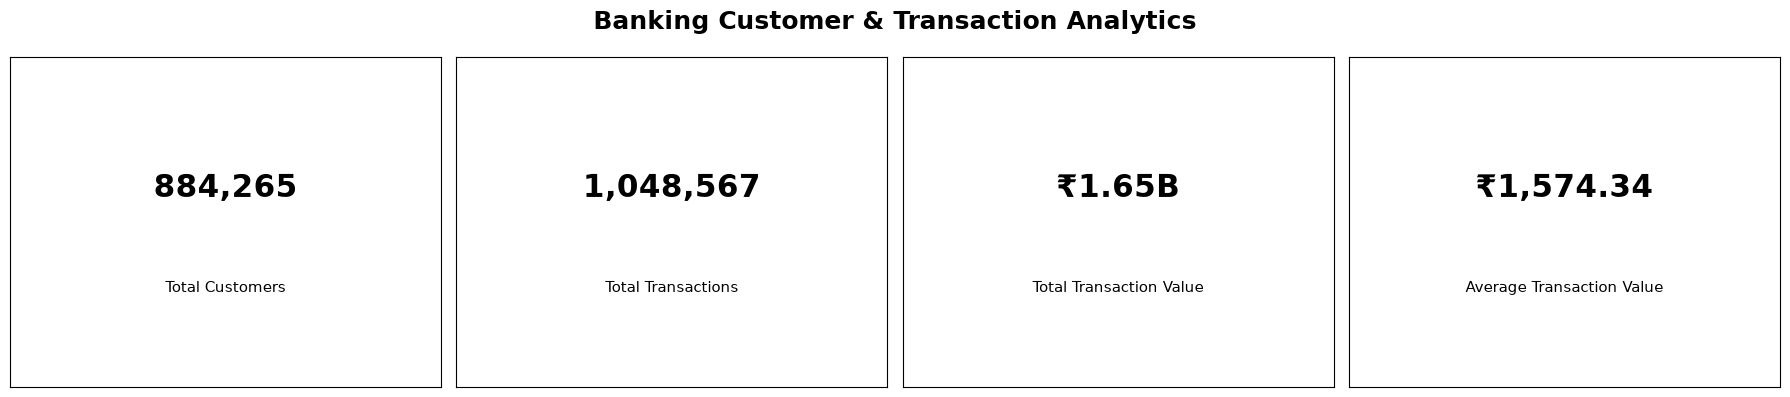

=== DASHBOARD KPI CARDS ===
KPI Cards berhasil dibuat.
KPI Cards disimpan di: ..\dashboard\dashboard_kpi_cards.png


In [207]:
# ============================================
# CELL 98 — DASHBOARD KPI CARDS
# ============================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

kpi_data = [
    (
        "Total Customers",
        f"{dashboard_kpi['Total Customers']:,}"
    ),
    (
        "Total Transactions",
        f"{dashboard_kpi['Total Transactions']:,}"
    ),
    (
        "Total Transaction Value",
        f"₹{dashboard_kpi['Total Transaction Value'] / 1_000_000_000:.2f}B"
    ),
    (
        "Average Transaction Value",
        f"₹{dashboard_kpi['Average Transaction Value']:,.2f}"
    )
]

for ax, (title, value) in zip(axes, kpi_data):
    ax.text(
        0.5,
        0.60,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)

fig.suptitle(
    "Banking Customer & Transaction Analytics",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

dashboard_kpi_path = DASHBOARD_PATH / "dashboard_kpi_cards.png"

plt.savefig(
    dashboard_kpi_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== DASHBOARD KPI CARDS ===")
print("KPI Cards berhasil dibuat.")
print(f"KPI Cards disimpan di: {dashboard_kpi_path}")

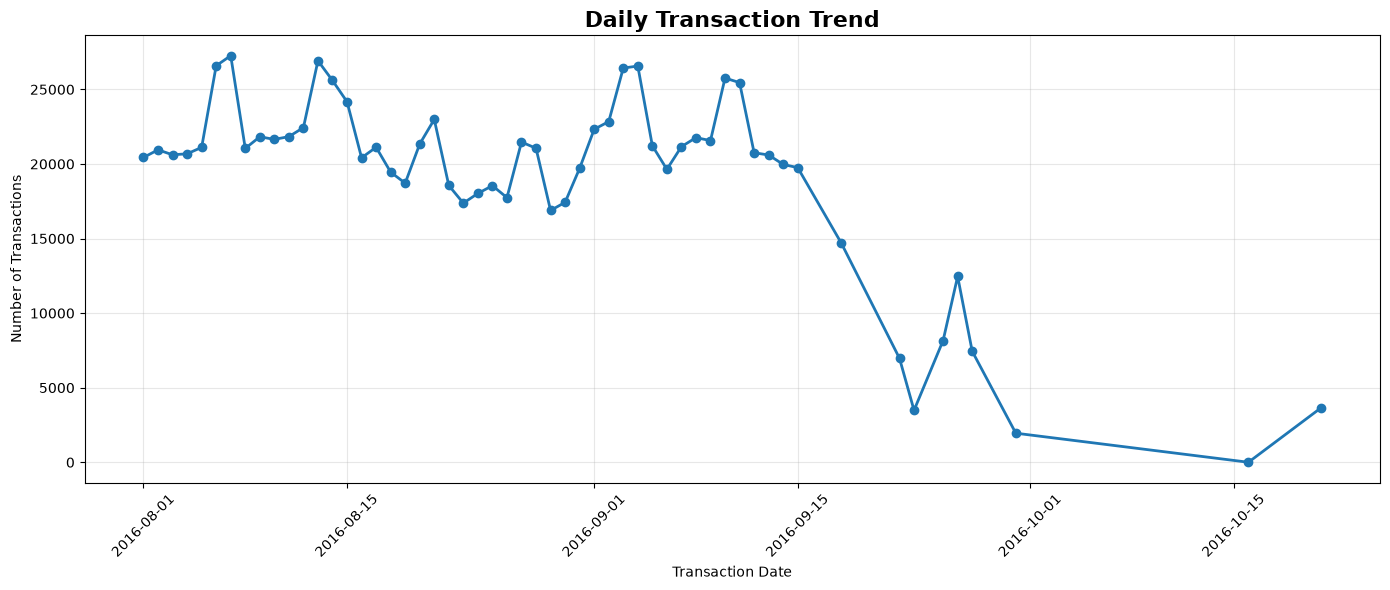

=== DASHBOARD TRANSACTION TREND ===
Transaction trend berhasil dibuat.
Chart disimpan di: ..\dashboard\dashboard_transaction_trend.png


In [209]:
# ============================================
# CELL 99 — DASHBOARD TRANSACTION TREND
# ============================================

daily_transaction_trend = (
    df_clean
    .groupby("TransactionDate")
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum")
    )
    .reset_index()
    .sort_values("TransactionDate")
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_transaction_trend["TransactionDate"],
    daily_transaction_trend["transaction_count"],
    marker="o",
    linewidth=2
)

plt.title(
    "Daily Transaction Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

transaction_trend_path = (
    DASHBOARD_PATH / "dashboard_transaction_trend.png"
)

plt.savefig(
    transaction_trend_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== DASHBOARD TRANSACTION TREND ===")
print("Transaction trend berhasil dibuat.")
print(f"Chart disimpan di: {transaction_trend_path}")

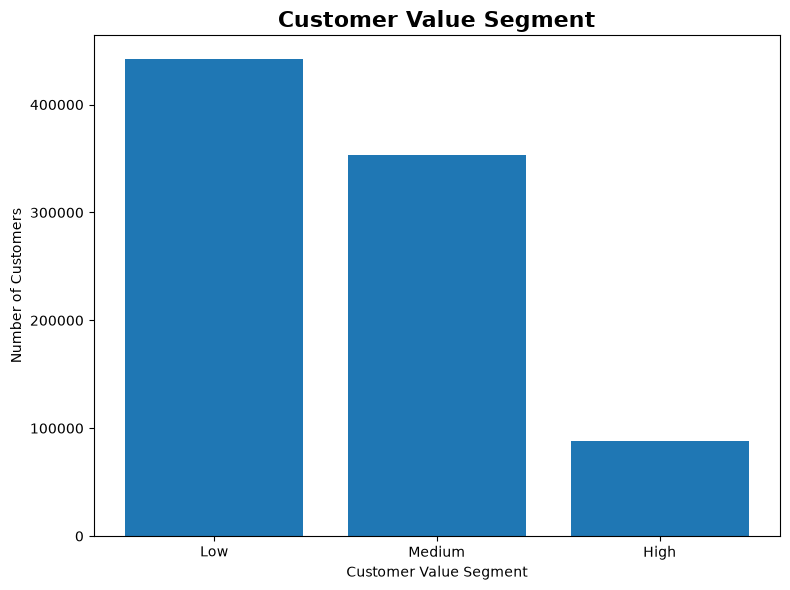

=== DASHBOARD CUSTOMER VALUE SEGMENT ===
CustomerValueSegment  customer_count  total_transaction_value
                 Low          442133             9.624265e+07
              Medium          353710             5.101641e+08
                High           88422             1.044389e+09

Customer value segment chart berhasil dibuat.
Chart disimpan di: ..\dashboard\dashboard_customer_value_segment.png


In [211]:
# ============================================
# CELL 100 — DASHBOARD CUSTOMER VALUE SEGMENT
# ============================================

customer_segment_dashboard = (
    df_clean
    .groupby("CustomerID")
    .agg(
        total_transaction_value=("TransactionAmount (INR)", "sum")
    )
    .reset_index()
)

customer_segment_dashboard["CustomerValueSegment"] = pd.cut(
    customer_segment_dashboard["total_transaction_value"],
    bins=[-np.inf, 536.80, 3577.00, np.inf],
    labels=["Low", "Medium", "High"]
)

segment_dashboard_summary = (
    customer_segment_dashboard
    .groupby("CustomerValueSegment", observed=False)
    .agg(
        customer_count=("CustomerID", "count"),
        total_transaction_value=("total_transaction_value", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(8, 6))

plt.bar(
    segment_dashboard_summary["CustomerValueSegment"],
    segment_dashboard_summary["customer_count"]
)

plt.title(
    "Customer Value Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Value Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

customer_segment_path = (
    DASHBOARD_PATH / "dashboard_customer_value_segment.png"
)

plt.savefig(
    customer_segment_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== DASHBOARD CUSTOMER VALUE SEGMENT ===")
print(
    segment_dashboard_summary.to_string(
        index=False
    )
)
print()
print("Customer value segment chart berhasil dibuat.")
print(f"Chart disimpan di: {customer_segment_path}")

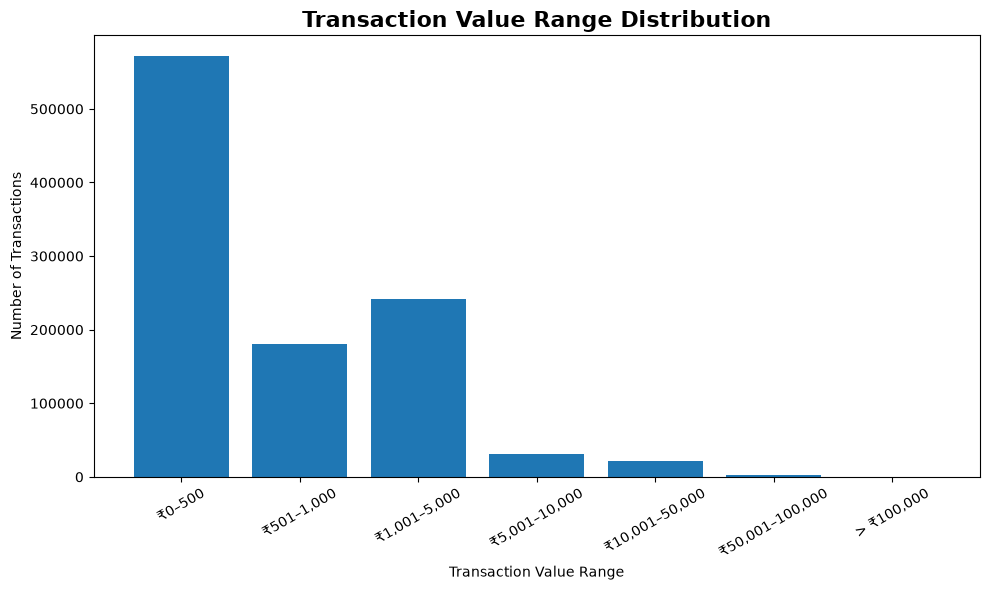

=== DASHBOARD TRANSACTION VALUE RANGE ===
TransactionValueRange  transaction_count  total_transaction_value
               ₹0–500             571386             116260176.08
           ₹501–1,000             180212             135334047.47
         ₹1,001–5,000             242182             522407983.51
        ₹5,001–10,000              30971             217770949.76
       ₹10,001–50,000              21436             433748513.57
      ₹50,001–100,000               1996             155070939.27
           > ₹100,000                384              70203121.91

Transaction value range chart berhasil dibuat.
Chart disimpan di: ..\dashboard\dashboard_transaction_value_range.png


In [213]:
# ============================================
# CELL 101 — DASHBOARD TRANSACTION VALUE RANGE
# ============================================

transaction_value_dashboard = df_clean[
    ["TransactionID", "TransactionAmount (INR)"]
].copy()

transaction_value_dashboard["TransactionValueRange"] = pd.cut(
    transaction_value_dashboard["TransactionAmount (INR)"],
    bins=[-np.inf, 500, 1000, 5000, 10000, 50000, 100000, np.inf],
    labels=[
        "₹0–500",
        "₹501–1,000",
        "₹1,001–5,000",
        "₹5,001–10,000",
        "₹10,001–50,000",
        "₹50,001–100,000",
        "> ₹100,000"
    ],
    include_lowest=True
)

value_range_summary = (
    transaction_value_dashboard
    .groupby("TransactionValueRange", observed=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    value_range_summary["TransactionValueRange"],
    value_range_summary["transaction_count"]
)

plt.title(
    "Transaction Value Range Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Value Range")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.tight_layout()

transaction_value_range_path = (
    DASHBOARD_PATH / "dashboard_transaction_value_range.png"
)

plt.savefig(
    transaction_value_range_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== DASHBOARD TRANSACTION VALUE RANGE ===")
print(
    value_range_summary.to_string(
        index=False
    )
)
print()
print("Transaction value range chart berhasil dibuat.")
print(f"Chart disimpan di: {transaction_value_range_path}")

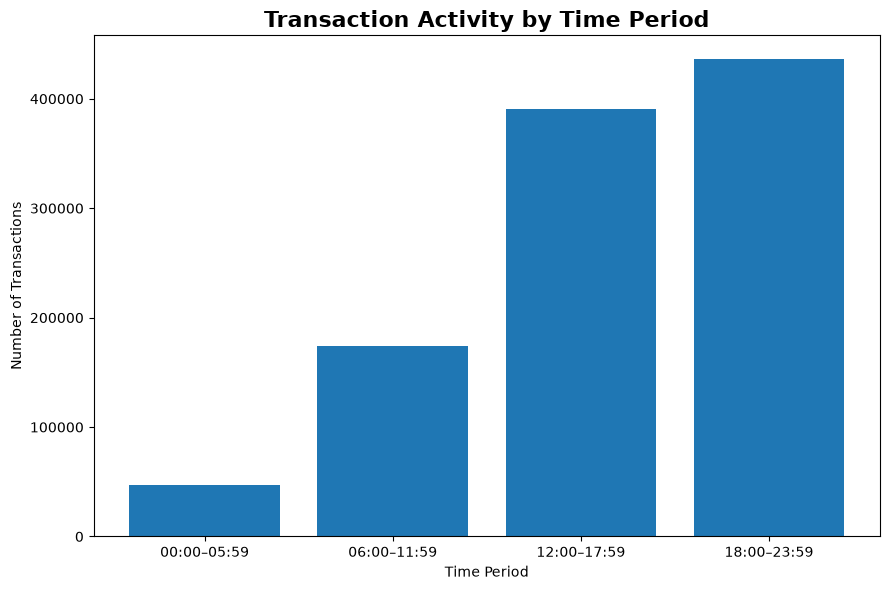

=== DASHBOARD TRANSACTION TIME PERIOD ===
TransactionTimePeriod  transaction_count  total_transaction_value
          00:00–05:59              47031              56273379.71
          06:00–11:59             174473             223807919.22
          12:00–17:59             390884             715112023.53
          18:00–23:59             436179             655602409.11

Transaction time period chart berhasil dibuat.
Chart disimpan di: ..\dashboard\dashboard_transaction_time_period.png


In [215]:
# ============================================
# CELL 102 — DASHBOARD TRANSACTION TIME PERIOD
# ============================================

time_period_dashboard = (
    df_clean
    .assign(
        TransactionTimePeriod=pd.cut(
            df_clean["TransactionHour"],
            bins=[-1, 5, 11, 17, 23],
            labels=[
                "00:00–05:59",
                "06:00–11:59",
                "12:00–17:59",
                "18:00–23:59"
            ]
        )
    )
    .groupby("TransactionTimePeriod", observed=False)
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(9, 6))

plt.bar(
    time_period_dashboard["TransactionTimePeriod"],
    time_period_dashboard["transaction_count"]
)

plt.title(
    "Transaction Activity by Time Period",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time Period")
plt.ylabel("Number of Transactions")

plt.tight_layout()

time_period_path = (
    DASHBOARD_PATH / "dashboard_transaction_time_period.png"
)

plt.savefig(
    time_period_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== DASHBOARD TRANSACTION TIME PERIOD ===")
print(
    time_period_dashboard.to_string(
        index=False
    )
)
print()
print("Transaction time period chart berhasil dibuat.")
print(f"Chart disimpan di: {time_period_path}")

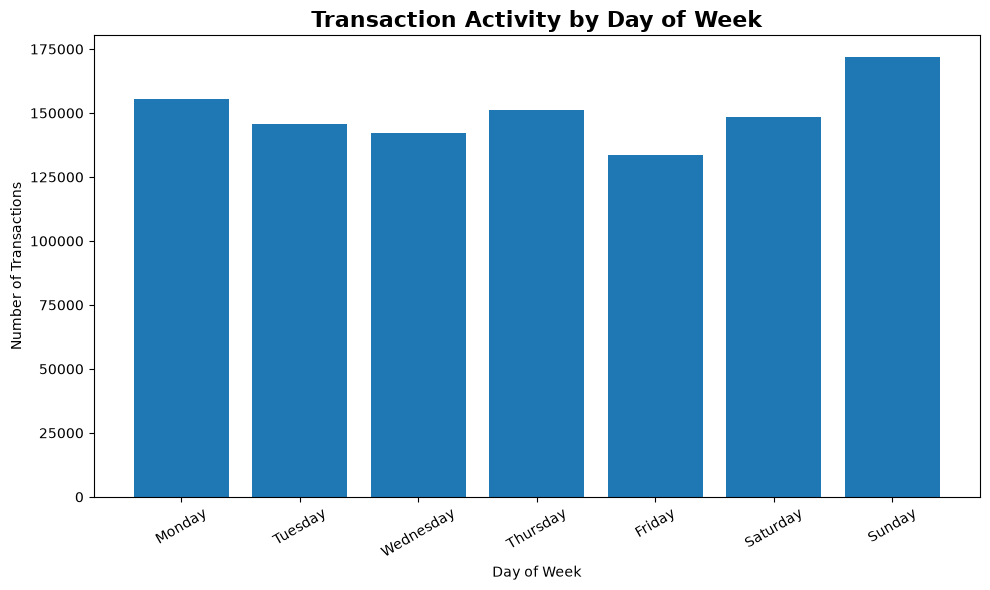

=== DASHBOARD TRANSACTION BY DAY ===
TransactionDayName  transaction_count  total_transaction_value
            Monday             155525             242755578.78
           Tuesday             145677             219535076.16
         Wednesday             142252             215891067.37
          Thursday             151331             236185271.18
            Friday             133505             208642653.59
          Saturday             148506             246667786.27
            Sunday             171771             281118298.22

Transaction by day chart berhasil dibuat.
Chart disimpan di: ..\dashboard\dashboard_transaction_by_day.png


In [217]:
# ============================================
# CELL 103 — DASHBOARD TRANSACTION BY DAY
# ============================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_dashboard = (
    df_clean
    .groupby("TransactionDayName")
    .agg(
        transaction_count=("TransactionID", "count"),
        total_transaction_value=("TransactionAmount (INR)", "sum")
    )
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    day_dashboard["TransactionDayName"],
    day_dashboard["transaction_count"]
)

plt.title(
    "Transaction Activity by Day of Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.tight_layout()

day_dashboard_path = (
    DASHBOARD_PATH / "dashboard_transaction_by_day.png"
)

plt.savefig(
    day_dashboard_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== DASHBOARD TRANSACTION BY DAY ===")
print(
    day_dashboard.to_string(
        index=False
    )
)
print()
print("Transaction by day chart berhasil dibuat.")
print(f"Chart disimpan di: {day_dashboard_path}")

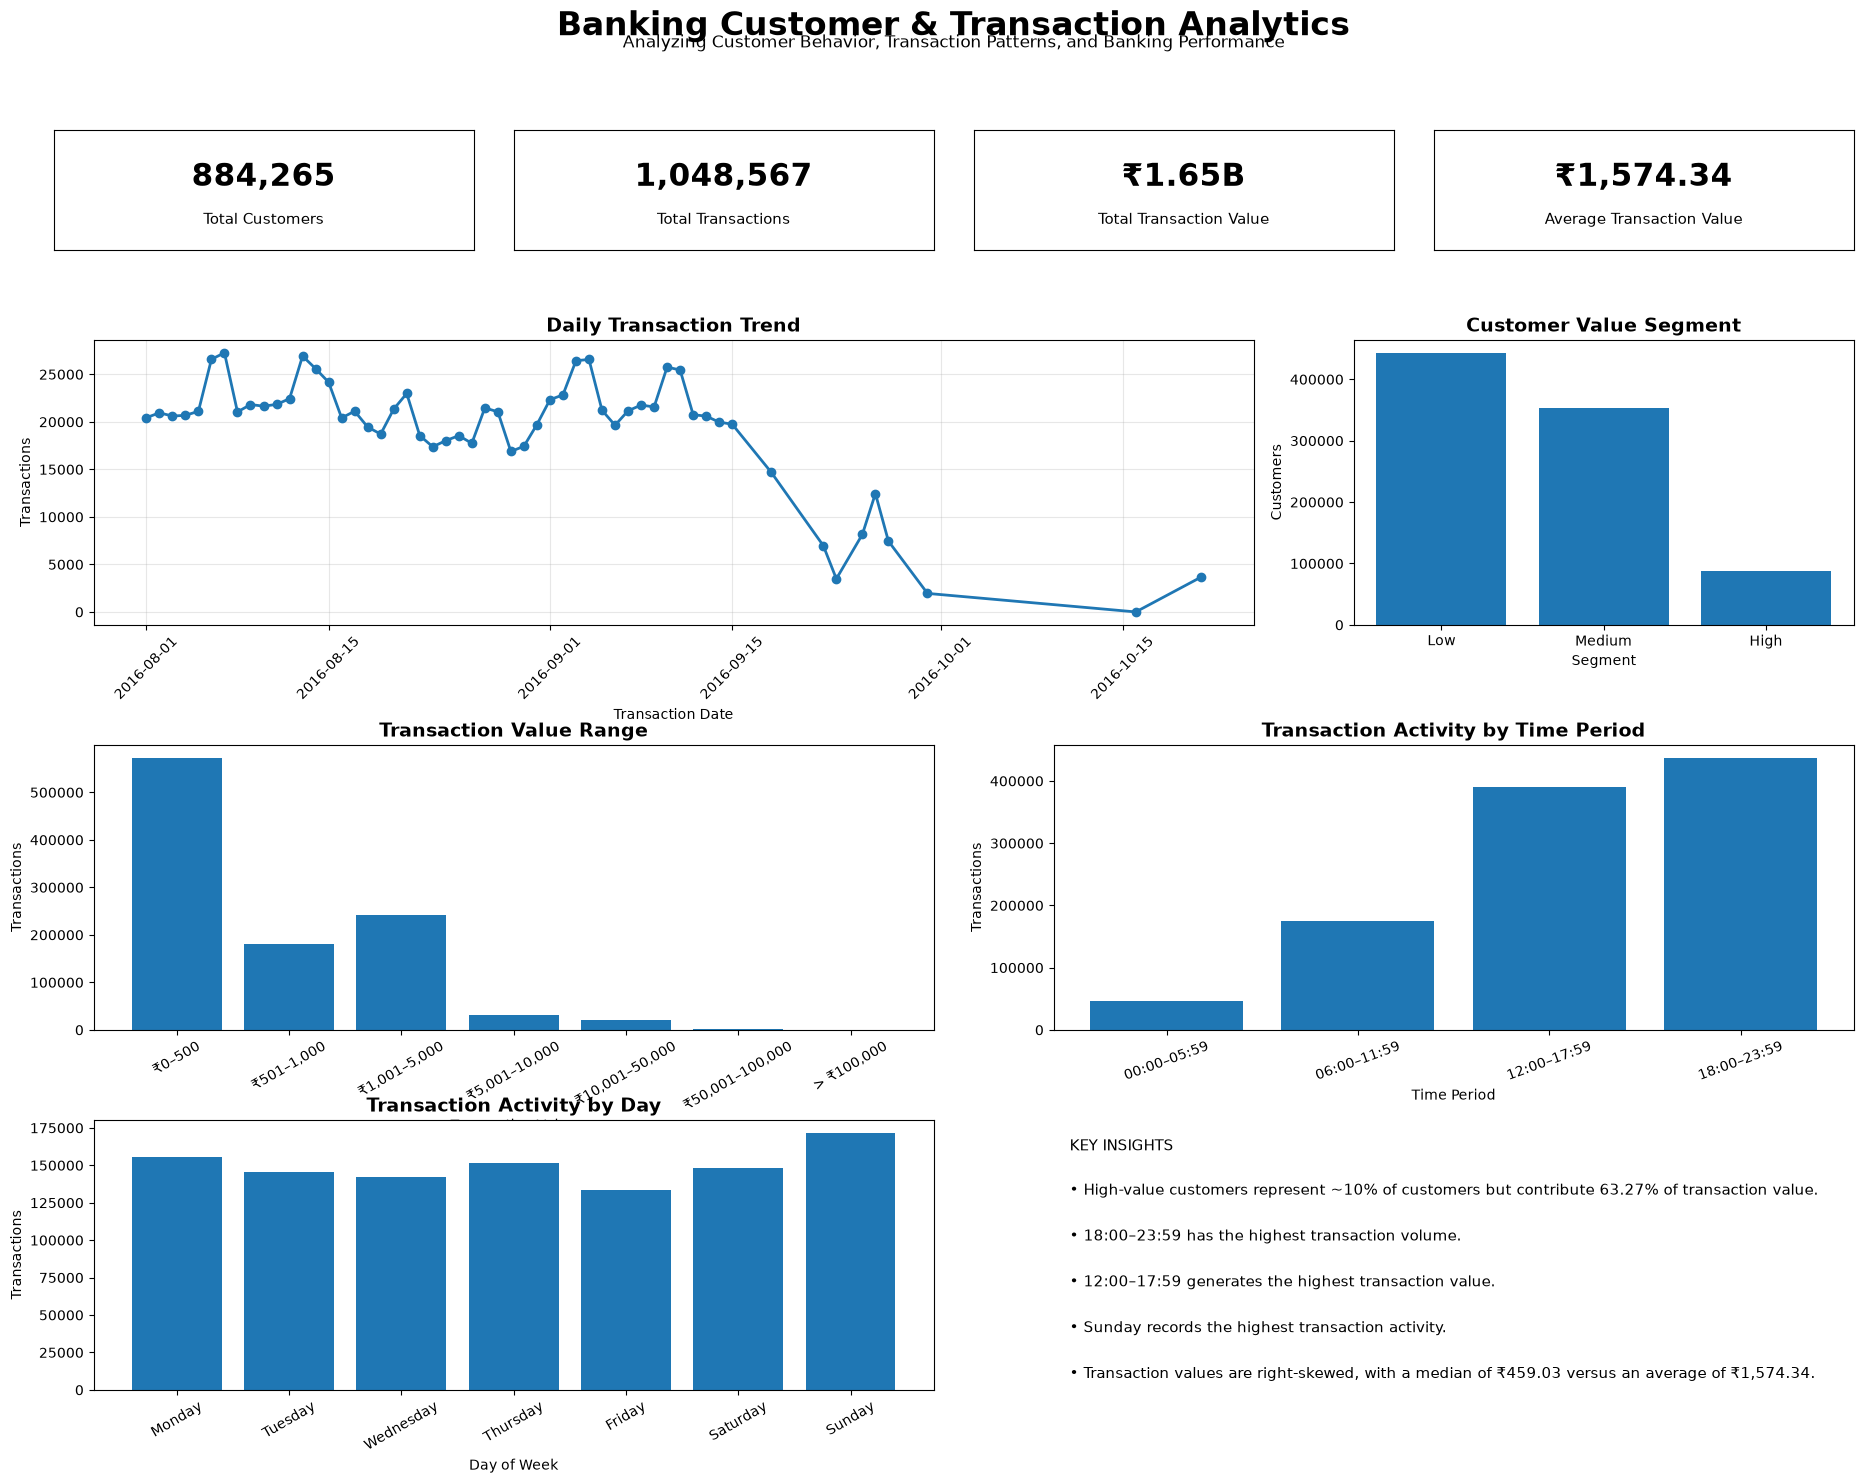

=== FINAL DASHBOARD ===
Final dashboard berhasil dibuat.
Dashboard disimpan di: ..\dashboard\banking_customer_transaction_dashboard.png


In [219]:
# ============================================
# CELL 104 — FINAL DASHBOARD
# ============================================

fig = plt.figure(figsize=(20, 15))

fig.suptitle(
    "Banking Customer & Transaction Analytics",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.955,
    "Analyzing Customer Behavior, Transaction Patterns, and Banking Performance",
    ha="center",
    fontsize=12
)

# ============================================
# 1. KPI CARDS
# ============================================

kpi_positions = [
    [0.05, 0.82, 0.21, 0.08],
    [0.28, 0.82, 0.21, 0.08],
    [0.51, 0.82, 0.21, 0.08],
    [0.74, 0.82, 0.21, 0.08]
]

kpi_data = [
    (
        "Total Customers",
        f"{dashboard_kpi['Total Customers']:,}"
    ),
    (
        "Total Transactions",
        f"{dashboard_kpi['Total Transactions']:,}"
    ),
    (
        "Total Transaction Value",
        f"₹{dashboard_kpi['Total Transaction Value'] / 1_000_000_000:.2f}B"
    ),
    (
        "Average Transaction Value",
        f"₹{dashboard_kpi['Average Transaction Value']:,.2f}"
    )
]

for position, (title, value) in zip(kpi_positions, kpi_data):

    ax = fig.add_axes(position)

    ax.text(
        0.5,
        0.60,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.25,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)


# ============================================
# 2. DAILY TRANSACTION TREND
# ============================================

ax1 = fig.add_axes([0.07, 0.57, 0.58, 0.19])

ax1.plot(
    daily_transaction_trend["TransactionDate"],
    daily_transaction_trend["transaction_count"],
    marker="o",
    linewidth=2
)

ax1.set_title(
    "Daily Transaction Trend",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Transaction Date")
ax1.set_ylabel("Transactions")

ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)


# ============================================
# 3. CUSTOMER VALUE SEGMENT
# ============================================

ax2 = fig.add_axes([0.70, 0.57, 0.25, 0.19])

ax2.bar(
    segment_dashboard_summary["CustomerValueSegment"],
    segment_dashboard_summary["customer_count"]
)

ax2.set_title(
    "Customer Value Segment",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Segment")
ax2.set_ylabel("Customers")


# ============================================
# 4. TRANSACTION VALUE RANGE
# ============================================

ax3 = fig.add_axes([0.07, 0.30, 0.42, 0.19])

ax3.bar(
    value_range_summary["TransactionValueRange"],
    value_range_summary["transaction_count"]
)

ax3.set_title(
    "Transaction Value Range",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("Transaction Value")
ax3.set_ylabel("Transactions")

ax3.tick_params(axis="x", rotation=30)


# ============================================
# 5. TRANSACTION BY TIME PERIOD
# ============================================

ax4 = fig.add_axes([0.55, 0.30, 0.40, 0.19])

ax4.bar(
    time_period_dashboard["TransactionTimePeriod"],
    time_period_dashboard["transaction_count"]
)

ax4.set_title(
    "Transaction Activity by Time Period",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Time Period")
ax4.set_ylabel("Transactions")

ax4.tick_params(axis="x", rotation=20)


# ============================================
# 6. TRANSACTION BY DAY OF WEEK
# ============================================

ax5 = fig.add_axes([0.07, 0.06, 0.42, 0.18])

ax5.bar(
    day_dashboard["TransactionDayName"],
    day_dashboard["transaction_count"]
)

ax5.set_title(
    "Transaction Activity by Day",
    fontsize=14,
    fontweight="bold"
)

ax5.set_xlabel("Day of Week")
ax5.set_ylabel("Transactions")

ax5.tick_params(axis="x", rotation=30)


# ============================================
# 7. KEY INSIGHT
# ============================================

ax6 = fig.add_axes([0.55, 0.06, 0.40, 0.18])

ax6.axis("off")

insight_text = (
    "KEY INSIGHTS\n\n"
    "• High-value customers represent ~10% of customers "
    "but contribute 63.27% of transaction value.\n\n"
    "• 18:00–23:59 has the highest transaction volume.\n\n"
    "• 12:00–17:59 generates the highest transaction value.\n\n"
    "• Sunday records the highest transaction activity.\n\n"
    "• Transaction values are right-skewed, with a median "
    "of ₹459.03 versus an average of ₹1,574.34."
)

ax6.text(
    0.02,
    0.95,
    insight_text,
    va="top",
    fontsize=11,
    linespacing=1.5
)


# ============================================
# SAVE FINAL DASHBOARD
# ============================================

final_dashboard_path = (
    DASHBOARD_PATH / "banking_customer_transaction_dashboard.png"
)

plt.savefig(
    final_dashboard_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== FINAL DASHBOARD ===")
print("Final dashboard berhasil dibuat.")
print(f"Dashboard disimpan di: {final_dashboard_path}")

In [221]:
# ============================================
# CELL 105 — EXPORT SQL ANALYSIS
# ============================================

SQL_PATH = Path("../sql")
SQL_PATH.mkdir(parents=True, exist_ok=True)

sql_file_path = SQL_PATH / "banking_analysis.sql"

sql_content = """
-- ============================================================
-- BANKING CUSTOMER & TRANSACTION ANALYTICS
-- SQL ANALYSIS
-- ============================================================

-- Database table:
-- bank_transactions


-- ============================================================
-- 1. TOTAL CUSTOMERS AND TRANSACTIONS
-- ============================================================

SELECT
    COUNT(DISTINCT CustomerID) AS total_customers,
    COUNT(TransactionID) AS total_transactions
FROM bank_transactions;


-- ============================================================
-- 2. TRANSACTION VALUE SUMMARY
-- ============================================================

SELECT
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value,
    MIN("TransactionAmount (INR)") AS minimum_transaction_value,
    MAX("TransactionAmount (INR)") AS maximum_transaction_value
FROM bank_transactions;


-- ============================================================
-- 3. TOP CUSTOMERS BY TRANSACTION VALUE
-- ============================================================

SELECT
    CustomerID,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value
FROM bank_transactions
GROUP BY CustomerID
ORDER BY total_transaction_value DESC
LIMIT 20;


-- ============================================================
-- 4. CUSTOMER TRANSACTION FREQUENCY
-- ============================================================

WITH customer_frequency AS (
    SELECT
        CustomerID,
        COUNT(TransactionID) AS transaction_count
    FROM bank_transactions
    GROUP BY CustomerID
)

SELECT
    transaction_count,
    COUNT(CustomerID) AS customer_count
FROM customer_frequency
GROUP BY transaction_count
ORDER BY transaction_count;


-- ============================================================
-- 5. TRANSACTION BY MONTH
-- ============================================================

SELECT
    strftime('%Y-%m', TransactionDate) AS transaction_month,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY strftime('%Y-%m', TransactionDate)
ORDER BY transaction_month;


-- ============================================================
-- 6. TRANSACTION BY HOUR
-- ============================================================

SELECT
    TransactionHour,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY TransactionHour
ORDER BY TransactionHour;


-- ============================================================
-- 7. TRANSACTION BY DAY OF WEEK
-- ============================================================

SELECT
    TransactionDayName,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY TransactionDayName
ORDER BY transaction_count DESC;


-- ============================================================
-- 8. CUSTOMER VALUE SEGMENT
-- ============================================================

WITH customer_value AS (
    SELECT
        CustomerID,
        SUM("TransactionAmount (INR)") AS total_transaction_value
    FROM bank_transactions
    GROUP BY CustomerID
),

customer_segment AS (
    SELECT
        CustomerID,
        total_transaction_value,
        CASE
            WHEN total_transaction_value <= 536.80
                THEN 'Low'
            WHEN total_transaction_value <= 3577.00
                THEN 'Medium'
            ELSE 'High'
        END AS customer_value_segment
    FROM customer_value
)

SELECT
    customer_value_segment,
    COUNT(CustomerID) AS customer_count,
    SUM(total_transaction_value) AS total_transaction_value,
    ROUND(
        SUM(total_transaction_value) * 100.0 /
        (SELECT SUM(total_transaction_value)
         FROM customer_value),
        2
    ) AS transaction_value_percentage
FROM customer_segment
GROUP BY customer_value_segment
ORDER BY
    CASE customer_value_segment
        WHEN 'Low' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'High' THEN 3
    END;


-- ============================================================
-- 9. TRANSACTION VALUE RANGE
-- ============================================================

SELECT
    CASE
        WHEN "TransactionAmount (INR)" <= 500
            THEN '₹0–500'
        WHEN "TransactionAmount (INR)" <= 1000
            THEN '₹501–1,000'
        WHEN "TransactionAmount (INR)" <= 5000
            THEN '₹1,001–5,000'
        WHEN "TransactionAmount (INR)" <= 10000
            THEN '₹5,001–10,000'
        WHEN "TransactionAmount (INR)" <= 50000
            THEN '₹10,001–50,000'
        WHEN "TransactionAmount (INR)" <= 100000
            THEN '₹50,001–100,000'
        ELSE '> ₹100,000'
    END AS transaction_value_range,

    COUNT(TransactionID) AS transaction_count,

    SUM("TransactionAmount (INR)") AS total_transaction_value,

    AVG("TransactionAmount (INR)") AS average_transaction_value

FROM bank_transactions

GROUP BY transaction_value_range

ORDER BY
    CASE transaction_value_range
        WHEN '₹0–500' THEN 1
        WHEN '₹501–1,000' THEN 2
        WHEN '₹1,001–5,000' THEN 3
        WHEN '₹5,001–10,000' THEN 4
        WHEN '₹10,001–50,000' THEN 5
        WHEN '₹50,001–100,000' THEN 6
        ELSE 7
    END;


-- ============================================================
-- 10. DAILY TRANSACTION PERFORMANCE
-- ============================================================

SELECT
    DATE(TransactionDate) AS transaction_date,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY DATE(TransactionDate)
ORDER BY transaction_date;


-- ============================================================
-- 11. PEAK TRANSACTION DAYS
-- ============================================================

SELECT
    DATE(TransactionDate) AS transaction_date,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY DATE(TransactionDate)
ORDER BY transaction_count DESC
LIMIT 10;


-- ============================================================
-- 12. PEAK DAYS BY TRANSACTION VALUE
-- ============================================================

SELECT
    DATE(TransactionDate) AS transaction_date,
    COUNT(TransactionID) AS transaction_count,
    SUM("TransactionAmount (INR)") AS total_transaction_value,
    AVG("TransactionAmount (INR)") AS average_transaction_value
FROM bank_transactions
GROUP BY DATE(TransactionDate)
ORDER BY total_transaction_value DESC
LIMIT 10;


-- ============================================================
-- 13. TRANSACTION ACTIVITY BY TIME PERIOD
-- ============================================================

SELECT
    CASE
        WHEN TransactionHour BETWEEN 0 AND 5
            THEN '00:00–05:59'
        WHEN TransactionHour BETWEEN 6 AND 11
            THEN '06:00–11:59'
        WHEN TransactionHour BETWEEN 12 AND 17
            THEN '12:00–17:59'
        ELSE '18:00–23:59'
    END AS transaction_time_period,

    COUNT(TransactionID) AS transaction_count,

    SUM("TransactionAmount (INR)") AS total_transaction_value,

    AVG("TransactionAmount (INR)") AS average_transaction_value

FROM bank_transactions

GROUP BY transaction_time_period

ORDER BY
    CASE transaction_time_period
        WHEN '00:00–05:59' THEN 1
        WHEN '06:00–11:59' THEN 2
        WHEN '12:00–17:59' THEN 3
        WHEN '18:00–23:59' THEN 4
    END;


-- ============================================================
-- 14. TRANSACTION VALUE DISTRIBUTION
-- ============================================================

WITH ordered_transactions AS (
    SELECT
        "TransactionAmount (INR)" AS transaction_amount,

        ROW_NUMBER() OVER (
            ORDER BY "TransactionAmount (INR)"
        ) AS row_number,

        COUNT(*) OVER () AS total_rows

    FROM bank_transactions
)

SELECT
    MIN(transaction_amount) AS minimum_transaction_value,

    MAX(transaction_amount) AS maximum_transaction_value,

    AVG(transaction_amount) AS average_transaction_value,

    (
        SELECT AVG(transaction_amount)
        FROM ordered_transactions
        WHERE row_number IN (
            CAST((total_rows + 1) / 2 AS INTEGER),
            CAST((total_rows + 2) / 2 AS INTEGER)
        )
    ) AS median_transaction_value

FROM ordered_transactions;


-- ============================================================
-- END OF SQL ANALYSIS
-- ============================================================
"""

with open(sql_file_path, "w", encoding="utf-8") as file:
    file.write(sql_content)

print("=== EXPORT SQL ANALYSIS ===")
print("SQL analysis berhasil dibuat.")
print(f"SQL file disimpan di: {sql_file_path}")

=== EXPORT SQL ANALYSIS ===
SQL analysis berhasil dibuat.
SQL file disimpan di: ..\sql\banking_analysis.sql


In [223]:
# ============================================
# CELL 106 — EXPORT BUSINESS INSIGHTS
# & RECOMMENDATIONS
# ============================================

INSIGHT_PATH = DASHBOARD_PATH / "business_insights.txt"

insights_content = """
BANKING CUSTOMER & TRANSACTION ANALYTICS
Business Insights & Recommendations
=====================================

BUSINESS INSIGHTS
-----------------

1. Customer and Transaction Overview
The dataset contains 884,265 unique customers and 1,048,567 transactions.

2. Customer Transaction Frequency
The average customer made 1.19 transactions, while the median transaction frequency was 1 transaction.
This indicates that most customers conducted only a small number of transactions during the observed period.

3. Customer Value Contribution
High-value customers represent approximately 10% of customers but contribute approximately 63.27% of total transaction value.
This indicates that a relatively small customer segment contributes a large proportion of transaction value.

4. Transaction Value Distribution
The median transaction value was INR 459.03, while the average transaction value was INR 1,574.34.
The difference indicates a right-skewed transaction value distribution, where relatively large transactions increase the average.

5. Transaction Value Range
The INR 1,001–5,000 transaction range generated the largest total transaction value.
Meanwhile, the INR 0–500 range contained the highest number of transactions.

6. Transaction Activity by Time
The 18:00–23:59 period recorded the highest number of transactions.
The 12:00–17:59 period generated the highest total transaction value.

7. Transaction Activity by Day
Sunday recorded the highest transaction count and the highest total transaction value among the days of the week.

8. Data Coverage Consideration
The dataset covers 1 August 2016 to 21 October 2016 with 55 unique transaction dates.
Some dates are missing and October represents only a partial period.
Therefore, comparisons involving the end of the observation period should be interpreted carefully.


BUSINESS RECOMMENDATIONS
------------------------

1. Customer Retention
Prioritize retention and relationship management for high-value customers because approximately 10% of customers contribute approximately 63.27% of total transaction value.

2. Customer Engagement
Develop strategies that encourage customers to make repeat transactions because the median customer transaction frequency is only 1 transaction.

3. Transaction Timing
Prioritize operational monitoring and service readiness during the 12:00–17:59 and 18:00–23:59 periods because these periods account for the highest transaction activity and value.

4. Weekend Activity
Evaluate service capacity and customer engagement opportunities during weekends, particularly Sunday, which records the highest transaction activity.

5. Transaction Value Monitoring
Monitor transaction value ranges separately to understand the contribution of low-value and high-value transactions to overall transaction performance.

6. Data Quality Monitoring
Improve monitoring of transaction-date completeness before conducting monthly trend comparisons to ensure that conclusions are not affected by incomplete date coverage.
"""

with open(
    INSIGHT_PATH,
    "w",
    encoding="utf-8"
) as file:
    file.write(insights_content)

print("=== EXPORT BUSINESS INSIGHTS ===")
print("Business insights dan recommendations berhasil dibuat.")
print(f"File disimpan di: {INSIGHT_PATH}")

=== EXPORT BUSINESS INSIGHTS ===
Business insights dan recommendations berhasil dibuat.
File disimpan di: ..\dashboard\business_insights.txt


In [225]:
# ============================================
# CELL 107 — FINAL PROJECT VERIFICATION
# ============================================

print("============================================")
print("FINAL PROJECT VERIFICATION")
print("============================================")

# ============================================
# 1. CHECK MAIN DATA FILES
# ============================================

print("\n[1] DATA FILES")

data_files = {
    "Raw Dataset": Path("../data/raw/bank_transactions.csv"),
    "Clean Dataset": Path("../data/processed/bank_transactions_clean.csv"),
    "SQLite Database": Path("../data/processed/banking_transactions.db")
}

for name, path in data_files.items():
    print(f"{name:<20}: {'OK' if path.exists() else 'NOT FOUND'}")


# ============================================
# 2. CHECK NOTEBOOK
# ============================================

print("\n[2] NOTEBOOK")

notebook_path = Path("../notebooks/banking_transaction_analysis.ipynb")

print(
    f"{'Notebook':<20}: "
    f"{'OK' if notebook_path.exists() else 'NOT FOUND'}"
)


# ============================================
# 3. CHECK SQL FILE
# ============================================

print("\n[3] SQL")

sql_file = Path("../sql/banking_analysis.sql")

print(
    f"{'SQL Analysis':<20}: "
    f"{'OK' if sql_file.exists() else 'NOT FOUND'}"
)


# ============================================
# 4. CHECK DASHBOARD FILES
# ============================================

print("\n[4] DASHBOARD FILES")

dashboard_files = [
    "dashboard_kpi_cards.png",
    "dashboard_transaction_trend.png",
    "dashboard_customer_value_segment.png",
    "dashboard_transaction_value_range.png",
    "dashboard_transaction_time_period.png",
    "dashboard_transaction_by_day.png",
    "banking_customer_transaction_dashboard.png",
    "business_insights.txt"
]

for filename in dashboard_files:

    path = DASHBOARD_PATH / filename

    print(
        f"{filename:<45}: "
        f"{'OK' if path.exists() else 'NOT FOUND'}"
    )


# ============================================
# 5. CHECK IMAGE OUTPUTS
# ============================================

print("\n[5] IMAGE OUTPUTS")

image_count = len(list(IMAGES_PATH.glob("*.png")))

print(f"PNG files in images folder: {image_count}")


# ============================================
# 6. FINAL DATASET CHECK
# ============================================

print("\n[6] FINAL DATASET")

print(f"Rows              : {len(df_clean):,}")
print(f"Columns           : {len(df_clean.columns):,}")
print(
    f"Unique customers  : "
    f"{df_clean['CustomerID'].nunique():,}"
)
print(
    f"Unique transactions: "
    f"{df_clean['TransactionID'].nunique():,}"
)


# ============================================
# 7. FINAL STATUS
# ============================================

required_paths = [
    Path("../data/raw/bank_transactions.csv"),
    Path("../data/processed/bank_transactions_clean.csv"),
    Path("../data/processed/banking_transactions.db"),
    Path("../sql/banking_analysis.sql"),
    DASHBOARD_PATH / "banking_customer_transaction_dashboard.png",
    DASHBOARD_PATH / "business_insights.txt"
]

all_ready = all(path.exists() for path in required_paths)

print("\n============================================")

if all_ready:
    print("FINAL STATUS : PROJECT READY")
else:
    print("FINAL STATUS : CHECK MISSING FILES")

print("============================================")

FINAL PROJECT VERIFICATION

[1] DATA FILES
Raw Dataset         : OK
Clean Dataset       : OK
SQLite Database     : OK

[2] NOTEBOOK
Notebook            : NOT FOUND

[3] SQL
SQL Analysis        : OK

[4] DASHBOARD FILES
dashboard_kpi_cards.png                      : OK
dashboard_transaction_trend.png              : OK
dashboard_customer_value_segment.png         : OK
dashboard_transaction_value_range.png        : OK
dashboard_transaction_time_period.png        : OK
dashboard_transaction_by_day.png             : OK
banking_customer_transaction_dashboard.png   : OK
business_insights.txt                        : OK

[5] IMAGE OUTPUTS
PNG files in images folder: 14

[6] FINAL DATASET
Rows              : 1,048,567
Columns           : 19
Unique customers  : 884,265
Unique transactions: 1,048,567

FINAL STATUS : PROJECT READY
